

# **Importação de Bibliotecas e Carregamento dos Dados**

In [ ]:
import string
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import numpy as np
from scipy.stats import chi2_contingency

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/7 semester/Projeto de Bloco 7/adult.csv")

def print_formatado(*args, prefixo=5, largura_total=100):
    titulo = " ".join(str(a) for a in args)
    print("\n")
    print("=" * 100)
    print(titulo)
    print("=" * 100)


Mounted at /content/drive


# **Inspeção Inicial**

In [ ]:
print_formatado("1. Tamanho do dataset:")
print(df.shape)

print_formatado("2. Variáveis do dataset:")
print(df.columns)

print_formatado("3. Signficado colunas:")
print("Ver Markdown")

print_formatado("4. Tipos dos dados:")
print(df.dtypes)

print_formatado("5. Organização Registros:")
df.info()
print("Ver Markdown")

print_formatado("6. Exemplo de valores:")
print("\nPrimeiros registros:")
print(df.head())

print("\nÚltimos registros:")
print(df.tail())

print("\nRegistros aleatórios:")
print(df.sample(5, random_state=1))


print_formatado("7. Identificação das variáveis")
print("\nVariáveis numéricas:")
print(f"age: min={df['age'].min()}, max={df['age'].max()}, média={df['age'].mean():.2f}")
print(f"fnlwgt: min={df['fnlwgt'].min()}, max={df['fnlwgt'].max()}, média={df['fnlwgt'].mean():.2f}")
print(f"education.num: min={df['education.num'].min()}, max={df['education.num'].max()}, média={df['education.num'].mean():.2f}")
print(f"capital.gain: min={df['capital.gain'].min()}, max={df['capital.gain'].max()}, média={df['capital.gain'].mean():.2f}")
print(f"capital.loss: min={df['capital.loss'].min()}, max={df['capital.loss'].max()}, média={df['capital.loss'].mean():.2f}")
print(f"hours.per.week: min={df['hours.per.week'].min()}, max={df['hours.per.week'].max()}, média={df['hours.per.week'].mean():.2f}")

print("\nVariáveis categóricas:")
print(f"workclass: {df['workclass'].unique().tolist()}")
print(f"education: {df['education'].unique().tolist()}")
print(f"marital status: {df['marital.status'].unique().tolist()}")
print(f"occupation: {df['occupation'].unique().tolist()}")
print(f"relationship: {df['relationship'].unique().tolist()}")
print(f"race: {df['race'].unique().tolist()}")
print(f"sex: {df['sex'].unique().tolist()}")
print(f"native country: {df['native.country'].unique().tolist()}")
print(f"income: {df['income'].unique().tolist()}")

print("\nVariáveis textuais:")
print("Ver Markdown")


print_formatado("8. Variáveis relevantes para o objetivo da análise")
print("Ver Markdown")


print_formatado("9. Possíveis problemas nos dados")
print("Ver Markdown")



1. Tamanho do dataset:
(32561, 15)


2. Variáveis do dataset:
Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='object')


3. Signficado colunas:
Ver Markdown


4. Tipos dos dados:
age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object
dtype: object


5. Organização Registros:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age  

## **Observações Inspeção Inicial**

### 3. Significado das colunas

* **age**: Idade do indivíduo (numérica, 17 a 90 anos).
* **workclass**: Tipo de empregador (ex: `Private`, `Self-emp-not-inc`, `State-gov`). Contém valores ausentes representados por `'?'`.
* **fnlwgt**: *Final weight*. Peso estatístico atribuído pelo Census Bureau, representando quantas pessoas na população aquele registro representa.
* **education**: Nível mais alto de educação atingido (ex: `Bachelors`, `HS-grad`, `Masters`).
* **education.num**: Representação numérica do nível de educação (1 a 16), correspondente à coluna `education`.
* **marital.status**: Estado civil (ex: `Married-civ-spouse`, `Never-married`, `Divorced`).
* **occupation**: Tipo de ocupação (ex: `Adm-clerical`, `Exec-managerial`, `Craft-repair`). Contém valores ausentes representados por `'?'`.
* **relationship**: Papel do indivíduo na família (ex: `Husband`, `Wife`, `Not-in-family`, `Own-child`).
* **race**: Raça do indivíduo (ex: `White`, `Black`, `Asian-Pac-Islander`).
* **sex**: Sexo do indivíduo (`Male`, `Female`).
* **capital.gain**: Ganhos de capital registrados (0 a 99.999).
* **capital.loss**: Perdas de capital registradas (0 a 4.356).
* **hours.per.week**: Número de horas trabalhadas por semana (1 a 99).
* **native.country**: País de origem. Contém valores ausentes representados por `'?'`.
* **income**: Nível de renda (`<=50K` ou `>50K`). Esta é a variável alvo do problema.

### 5. Organização dos Registros

* O dataset possui **32.561 registros** e **15 colunas**, sem nenhum valor nulo explícito (`Non-Null Count` = 32561 em todas as colunas — `df.info()` não detecta os `'?'` como ausentes, pois são strings válidas).
* Os registros não parecem estar ordenados aleatoriamente: ao observar `head()` e `tail()`, nota-se, por exemplo, concentração de indivíduos mais velhos e com `income <=50K` no início do dataset.
* Todos os tipos de dados foram carregados corretamente pelo pandas: colunas numéricas como `int64` e colunas categóricas como `object`.

### 6. Exemplo de valores

* A amostragem de registros (primeiros, últimos e aleatórios) confirma a presença de valores `'?'` em colunas como `workclass` e `occupation`, indicando dados ausentes.

### 7. Identificação das variáveis

* **Numéricas**: `age`, `fnlwgt`, `education.num`, `capital.gain`, `capital.loss`, `hours.per.week`.
  * Destaque para `capital.gain` e `capital.loss`, cujas médias (1077,65 e 87,30, respectivamente) são muito menores que seus valores máximos (99.999 e 4.356), sugerindo forte assimetria (a maioria dos registros tem valor 0).
* **Categóricas**: `workclass`, `education`, `marital.status`, `occupation`, `relationship`, `race`, `sex`, `native.country`, `income`.
* **Textuais livres**: o dataset não possui variáveis textuais livres (como descrições ou comentários abertos).

### 8. Variáveis relevantes para o objetivo da análise

* **income**: variável alvo, indicando se a renda do indivíduo é `<=50K` ou `>50K`.
* Variáveis com forte potencial preditivo: `age`, `education`/`education.num`, `occupation`, `hours.per.week`, `capital.gain`, `capital.loss` e `marital.status`, por estarem tradicionalmente associadas a nível de renda.
* `fnlwgt` é uma variável de ponderação amostral e não deve ser usada diretamente como feature preditiva, pois não carrega informação

# **Verificação da Qualidade dos Dados**

In [ ]:
import unicodedata

colunas_categoricas = ["workclass", "education", "marital.status", "occupation", "relationship", "race", "sex", "native.country"]

print_formatado("1. Valores ausentes:")
print("Valores ausentes (NaN):")
print(df.isnull().sum())

print("\nValores ausentes representados por '?':")
for coluna in df.select_dtypes(include="object").columns:
    qtd_interrogacao = (df[coluna].str.strip() == "?").sum()
    print(f"{coluna:<15}: {qtd_interrogacao}")
print("Ver Markdown")

print_formatado("2. Registros duplicados:")
print("Duplicatas completas:")
print(df.duplicated().sum())

print("\nDuplicadas desconsiderando fnlwgt:")
print(df.drop(columns=["fnlwgt"]).duplicated().sum())
print("Ver Markdown")

print_formatado("3. Tipos de Dados:")
for coluna in df:
  print(df[coluna].apply(type).value_counts())

print("\nQuantidade de categorias por coluna:")
for coluna in df:
  print(f"{coluna:<15}: {df[coluna].nunique()}")

print("\nDistribuição absoluta:")
for coluna in df:
  if df[coluna].dtype != "object":
    continue
  print(df[coluna].value_counts(), "\n")
print("Ver Markdown")


print_formatado("4. Categorias escritas de maneira diferente:")
def normalizar_texto(valor):
  if pd.isna(valor):
    return valor

  valor = valor.strip().lower()
  valor = (
    unicodedata.normalize('NFKD', valor)
    .encode('ASCII', 'ignore')
    .decode('utf-8')
  )

  return valor

for coluna in colunas_categoricas:
  com_normalizacao = df[coluna].apply(normalizar_texto).nunique()
  sem_normalizacao = df[coluna].nunique()
  print(f"{coluna:<15} -> Com Normalização: {com_normalizacao} | Sem Normalização: {sem_normalizacao}")

print_formatado("5. Textos vazios ou espaços extras:")
for coluna in colunas_categoricas:
    qtd_espacos = (df[coluna] != df[coluna].str.strip()).sum()
    print(f"{coluna:<15}: {qtd_espacos}")

print_formatado("6. Valores impossíveis ou fora do contexto:")
print("\nValores impossíveis:")
print(f"age mínimo               : {df['age'].min()}")
print(f"age máximo               : {df['age'].max()}")
print(f"age < 17 ou > 90         : {df['age'][(df['age'] < 17) | (df['age'] > 90)].count()}")
print(f"hours.per.week mínimo    : {df['hours.per.week'].min()}")
print(f"hours.per.week máximo    : {df['hours.per.week'].max()}")
print(f"hours.per.week < 1 ou >99: {df['hours.per.week'][(df['hours.per.week'] < 1) | (df['hours.per.week'] > 99)].count()}")
print(f"capital.gain negativo    : {df['capital.gain'][df['capital.gain'] < 0].count()}")
print(f"capital.loss negativo    : {df['capital.loss'][df['capital.loss'] < 0].count()}")
print(f"education fora de contexto:\n{df.groupby('education')['education.num'].nunique()}")

print("\nInconsistência de capitalização (mesmo valor, cases diferentes):")
for coluna in colunas_categoricas:
    valores_lower = df[coluna].str.lower()
    qtd_original = df[coluna].nunique()
    qtd_lower = valores_lower.nunique()
    if qtd_original != qtd_lower:
        print(f"{coluna:<15}: {qtd_original} categorias originais -> {qtd_lower} após lowercase")
    else:
        print(f"{coluna:<15}: sem inconsistência de capitalização")

print("\nCaracteres inesperados (fora de letras, espaço, hífen e '&'):")
for coluna in colunas_categoricas:
    padrao = r"[^A-Za-z\s\-&]"
    qtd_estranhos = df[coluna][df[coluna].str.contains(padrao, na=False, regex=True)].nunique()
    valores_estranhos = df[coluna][df[coluna].str.contains(padrao, na=False, regex=True)].unique()
    if qtd_estranhos > 0:
        print(f"{coluna:<15}: {qtd_estranhos} valor(es) -> {list(valores_estranhos)}")
    else:
        print(f"{coluna:<15}: nenhum caractere inesperado")

print("\nConsistência entre 'education' e 'education.num' (mapeamento deveria ser 1 para 1):")
mapeamento = df.groupby("education")["education.num"].nunique()
inconsistentes = mapeamento[mapeamento > 1]
if len(inconsistentes) > 0:
    print(inconsistentes)
else:
    print("Nenhuma inconsistência encontrada.")



1. Valores ausentes:
Valores ausentes (NaN):
age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

Valores ausentes representados por '?':
workclass      : 1836
education      : 0
marital.status : 0
occupation     : 1843
relationship   : 0
race           : 0
sex            : 0
native.country : 583
income         : 0
Ver Markdown


2. Registros duplicados:
Duplicatas completas:
24

Duplicadas desconsiderando fnlwgt:
3465
Ver Markdown


3. Tipos de Dados:
age
<class 'int'>    32561
Name: count, dtype: int64
workclass
<class 'str'>    32561
Name: count, dtype: int64
fnlwgt
<class 'int'>    32561
Name: count, dtype: int64
education
<class 'str'>    32561
Name: count, dtype: int64
education.num
<class 'int'>    32561
Name: count, dty

## **Observações Qualidade dos Dados**

### 1. Valores ausentes e em qual quantidade
* ***Não há valores ausentes explícitos (`NaN`), mas há valores `'?'` nas colunas `workclass`, `occupation` e `native.country`, que representam dados ausentes.***
    * ***Converter as categorias com `'?'` para `Desconhecido` e manter os registros.***
### 2. Registros duplicados
* ***Há registros duplicados, tanto considerando todas as colunas quanto desconsiderando `fnlwgt`***.
    * ***Remover registros duplicados completos.***
        * ***Duplicadas sem fnlwgt: provavelmente coincidência, logo é provável que sejam válidas.***
### 3. Tipos dos dados estão corretos;
* ***Converter as variáveis categóricas (`workclass`, `education`, `marital.status`, `occupation`, `relationship`, `race`, `sex`, `native.country`, `income`) para o tipo `category`.***

### Outras observações:
* Não há categorias escritas de forma diferente (capitalização ou espaços extras) nas colunas categóricas.
* Não há caracteres inesperados nas colunas categóricas, além do `'?'` já identificado.
* Não há valores impossíveis ou fora do contexto em `age`, `hours.per.week`, `capital.gain` e `capital.loss`.
* Não há erros de digitação ou preenchimento; o mapeamento entre `education` e `education.num` é consistente (1 para 1).
* Em `native.country` o valor inesperado `Outlying-US(Guam-USVI-etc)` é uma categoria válida.

# **Limpeza e Preparação dos Dados**

In [ ]:
print_formatado("1. Remover/tratar registros duplicados desnecessários;")
print("\nRemover duplicadas completas:")

print(f"Duplicatas completas antes: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"\nDuplicatas completas depois: {df.duplicated().sum()}")

print_formatado("2. Remover/tratar valores ausentes tratados de forma justificada")

colunas_com_interrogacao = ["workclass", "occupation", "native.country"]
print("Quantidade de '?' antes do tratamento:")
for coluna in colunas_com_interrogacao:
    print(f"{coluna:<15}: {(df[coluna].str.strip() == '?').sum()}")
for coluna in colunas_com_interrogacao:
    df[coluna] = df[coluna].str.strip().replace("?", "Desconhecido")
print("\nQuantidade de '?' depois do tratamento:")
for coluna in colunas_com_interrogacao:
    print(f"{coluna:<15}: {(df[coluna] == '?').sum()}")

print_formatado("3. Corrigir tipos das colunas:")
colunas_categoricas = ["workclass", "education", "marital.status", "occupation",
                        "relationship", "race", "sex", "native.country", "income"]

print("Tipos antes da conversão:")
print(df[colunas_categoricas].dtypes)
for coluna in colunas_categoricas:
    df[coluna] = df[coluna].astype("category")
print("\nTipos depois da conversão:")
print(df[colunas_categoricas].dtypes)

print_formatado("4. Corrigir espaços, erros de preenchimento e inconsistências evidentes;")
print("Ver Markdown")

print_formatado("5. Corrigir valores inválidos;")
print("Ver Markdown")




1. Remover/tratar registros duplicados desnecessários;

Remover duplicadas completas:
Duplicatas completas antes: 24

Duplicatas completas depois: 0


2. Remover/tratar valores ausentes tratados de forma justificada
Quantidade de '?' antes do tratamento:
workclass      : 1836
occupation     : 1843
native.country : 582

Quantidade de '?' depois do tratamento:
workclass      : 0
occupation     : 0
native.country : 0


3. Corrigir tipos das colunas:
Tipos antes da conversão:
workclass         object
education         object
marital.status    object
occupation        object
relationship      object
race              object
sex               object
native.country    object
income            object
dtype: object

Tipos depois da conversão:
workclass         category
education         category
marital.status    category
occupation        category
relationship      category
race              category
sex               category
native.country    category
income            category
dtype: obje

## **Observações Limpeza e Preparação dos Dados**
### 4. Corrigir espaços, erros de preenchimento e inconsistências evidentes;
* Não há espaços, erros de preenchimento e inconsistências evidentes
### 5. Corrigir valores inválidos;
* Não há valores inválidos.

### 4. Corrigir espaços, erros de preenchimento e inconsistências evidentes;
* Não há espaços, erros de preenchimento e inconsistências evidentes.

### 5. Corrigir valores inválidos
* Não há valores inválidos.



# **Análise Univariada**

### **Variáveis numéricas**



1. Média, mediana, mínimo e máximo:

Variável 'age':
Média: 38.59
Mediana: 37.00
Mínimo: 17
Máximo: 90

Variável 'fnlwgt':
Média: 189780.85
Mediana: 178356.00
Mínimo: 12285
Máximo: 1484705

Variável 'education.num':
Média: 10.08
Mediana: 10.00
Mínimo: 1
Máximo: 16

Variável 'capital.gain':
Média: 1078.44
Mediana: 0.00
Mínimo: 0
Máximo: 99999

Variável 'capital.loss':
Média: 87.37
Mediana: 0.00
Mínimo: 0
Máximo: 4356

Variável 'hours.per.week':
Média: 40.44
Mediana: 40.00
Mínimo: 1
Máximo: 99


2. Quartis, variância e desvio-padrão:

Variável 'age':
Q1 (25%): 28.00
Q2 (50% - mediana): 37.00
Q3 (75%): 48.00
Variância: 185.99
Desvio-padrão: 13.64

Variável 'fnlwgt':
Q1 (25%): 117827.00
Q2 (50% - mediana): 178356.00
Q3 (75%): 236993.00
Variância: 11142168571.98
Desvio-padrão: 105556.47

Variável 'education.num':
Q1 (25%): 9.00
Q2 (50% - mediana): 10.00
Q3 (75%): 12.00
Variância: 6.61
Desvio-padrão: 2.57

Variável 'capital.gain':
Q1 (25%): 0.00
Q2 (50% - mediana): 0.00
Q3 (75%): 0.00
Vari

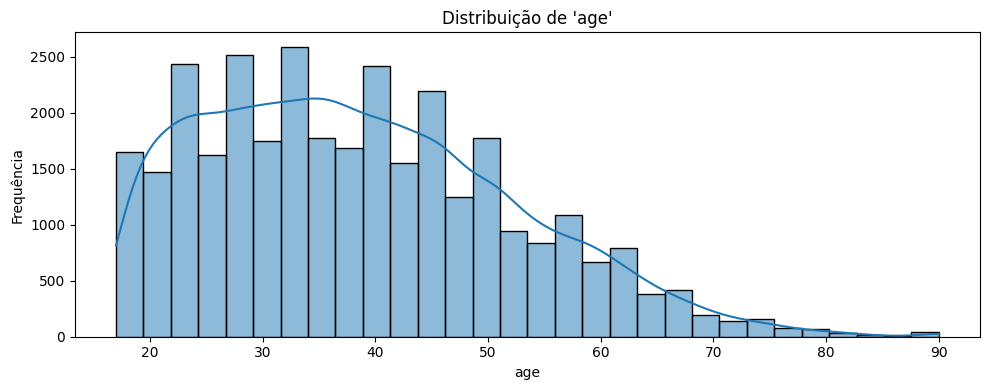


Variável 'fnlwgt':
count    3.253700e+04
mean     1.897808e+05
std      1.055565e+05
min      1.228500e+04
25%      1.178270e+05
50%      1.783560e+05
75%      2.369930e+05
max      1.484705e+06
Name: fnlwgt, dtype: float64


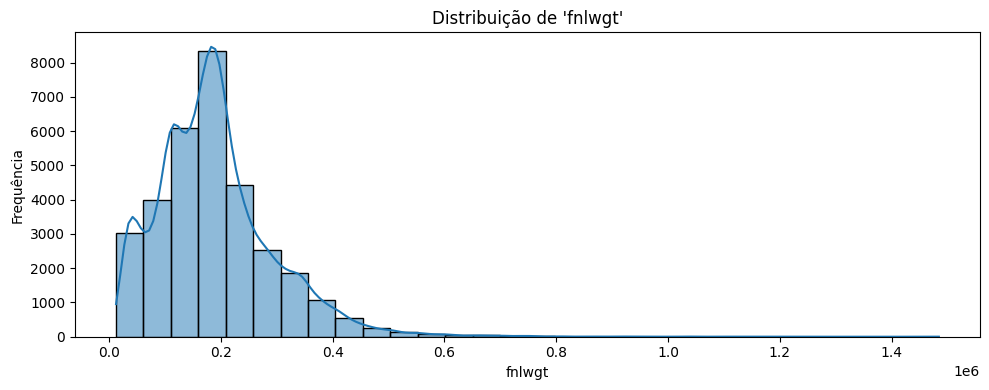


Variável 'education.num':
count    32537.000000
mean        10.081815
std          2.571633
min          1.000000
25%          9.000000
50%         10.000000
75%         12.000000
max         16.000000
Name: education.num, dtype: float64


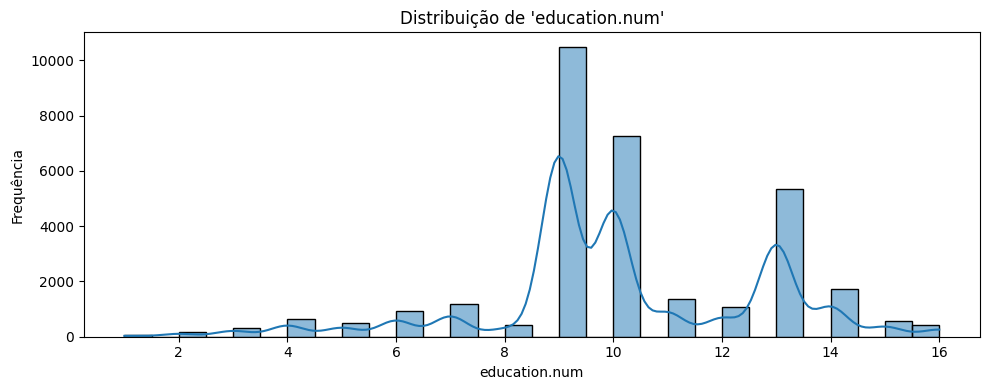


Variável 'capital.gain':
count    32537.000000
mean      1078.443741
std       7387.957424
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital.gain, dtype: float64


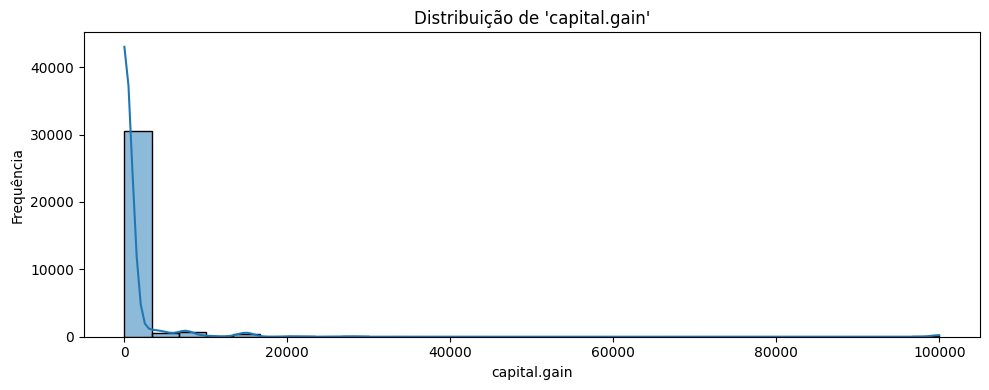


Variável 'capital.loss':
count    32537.000000
mean        87.368227
std        403.101833
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       4356.000000
Name: capital.loss, dtype: float64


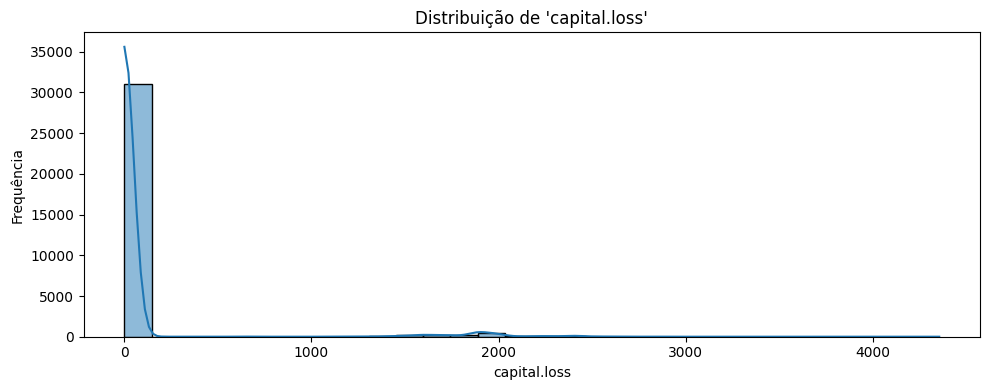


Variável 'hours.per.week':
count    32537.000000
mean        40.440329
std         12.346889
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours.per.week, dtype: float64


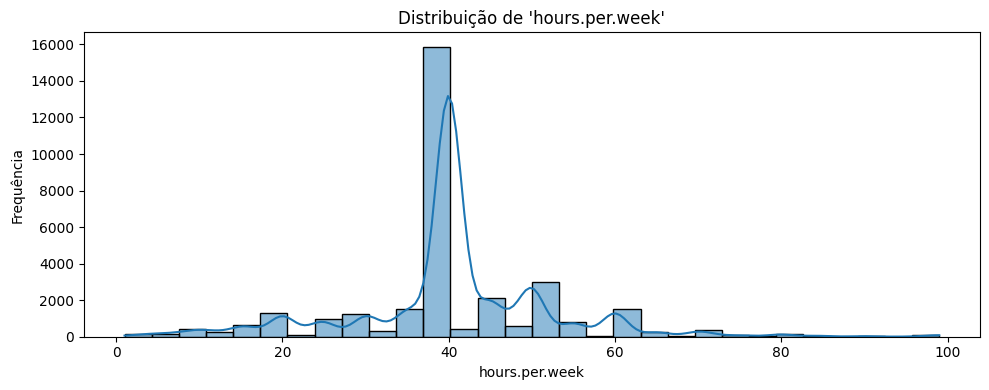

In [ ]:
colunas_numericas = ["age", "fnlwgt", "education.num", "capital.gain", "capital.loss", "hours.per.week"]

print_formatado("1. Média, mediana, mínimo e máximo:")
# calculca a estatística para cada coluna
for coluna in colunas_numericas:
    print(f"\nVariável '{coluna}':")
    print(f"Média: {df[coluna].mean():.2f}")
    print(f"Mediana: {df[coluna].median():.2f}")
    print(f"Mínimo: {df[coluna].min()}")
    print(f"Máximo: {df[coluna].max()}")

# calcula a dispersão dos dados
# 1 quartil -> 25% das amostras estão a baixo desse valor
# 2 quartil -> 50% das amostras estão a baixo desse valor
# 3 quartil -> 75% das amostras estão a baixo desse valor
print_formatado("2. Quartis, variância e desvio-padrão:")
for coluna in colunas_numericas:
    q1 = df[coluna].quantile(0.25)
    q2 = df[coluna].quantile(0.50)
    q3 = df[coluna].quantile(0.75)

    print(f"\nVariável '{coluna}':")
    print(f"Q1 (25%): {q1:.2f}")
    print(f"Q2 (50% - mediana): {q2:.2f}")
    print(f"Q3 (75%): {q3:.2f}")
    print(f"Variância: {df[coluna].var():.2f}")
    print(f"Desvio-padrão: {df[coluna].std():.2f}")  # quanto maior o desvio padrão, mais longe os dados estão da média

# histograma - ilustra no grafico os valores
print_formatado("3. Distribuição dos valores:")
for coluna in colunas_numericas:
    print(f"\nVariável '{coluna}':")
    print(df[coluna].describe())

    plt.figure(figsize=(10, 4))
    sns.histplot(df[coluna], kde=True, bins=30) # bins - numero d barras no data set
    plt.title(f"Distribuição de '{coluna}'")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()

### **Variáveis categóricas**

1. Quantidade de categorias:

Quantidade de categorias únicas por variável:
workclass          9
education         16
marital.status     7
occupation        15
relationship       6
race               5
sex                2
native.country    42
income             2
dtype: int64


2. Frequência absoluta e relativa:

Frequência absoluta:

Variável 'workclass':
workclass
Private             22673
Self-emp-not-inc     2540
Local-gov            2093
Desconhecido         1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64


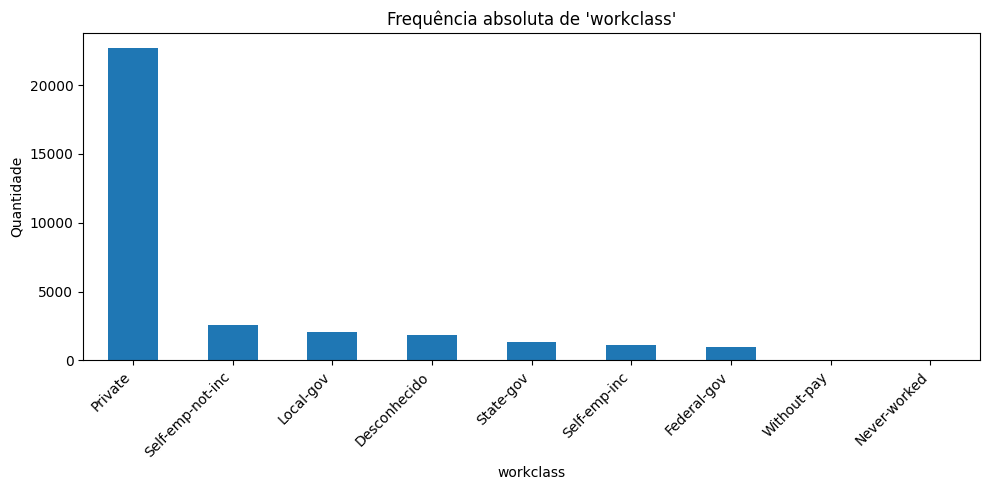


Variável 'education':
education
HS-grad         10494
Some-college     7282
Bachelors        5353
Masters          1722
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           645
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           332
1st-4th           166
Preschool          50
Name: count, dtype: int64


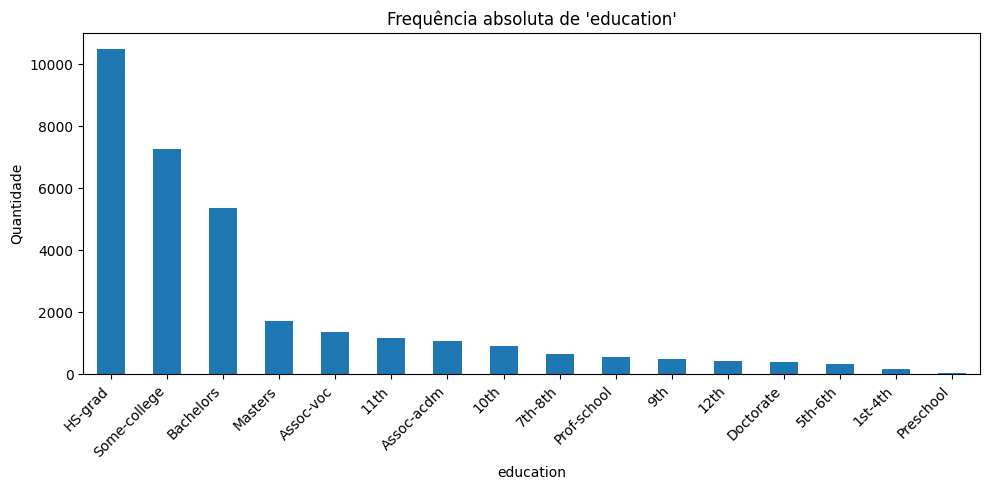


Variável 'marital.status':
marital.status
Married-civ-spouse       14970
Never-married            10667
Divorced                  4441
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64


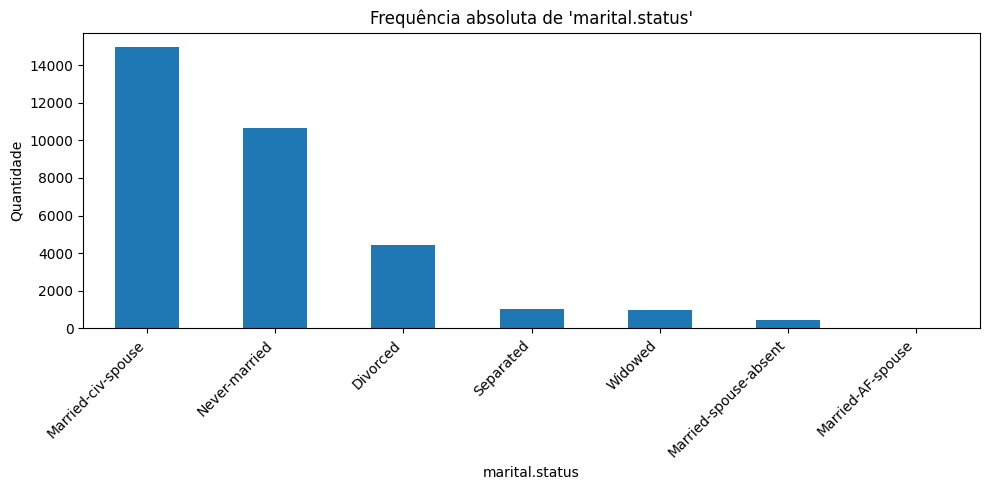


Variável 'occupation':
occupation
Prof-specialty       4136
Craft-repair         4094
Exec-managerial      4065
Adm-clerical         3768
Sales                3650
Other-service        3291
Machine-op-inspct    2000
Desconhecido         1843
Transport-moving     1597
Handlers-cleaners    1369
Farming-fishing       992
Tech-support          927
Protective-serv       649
Priv-house-serv       147
Armed-Forces            9
Name: count, dtype: int64


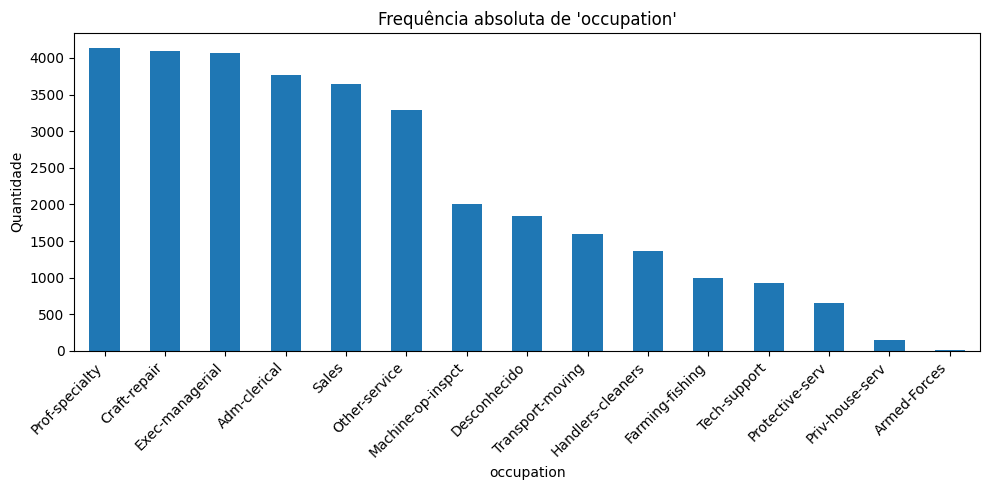


Variável 'relationship':
relationship
Husband           13187
Not-in-family      8292
Own-child          5064
Unmarried          3445
Wife               1568
Other-relative      981
Name: count, dtype: int64


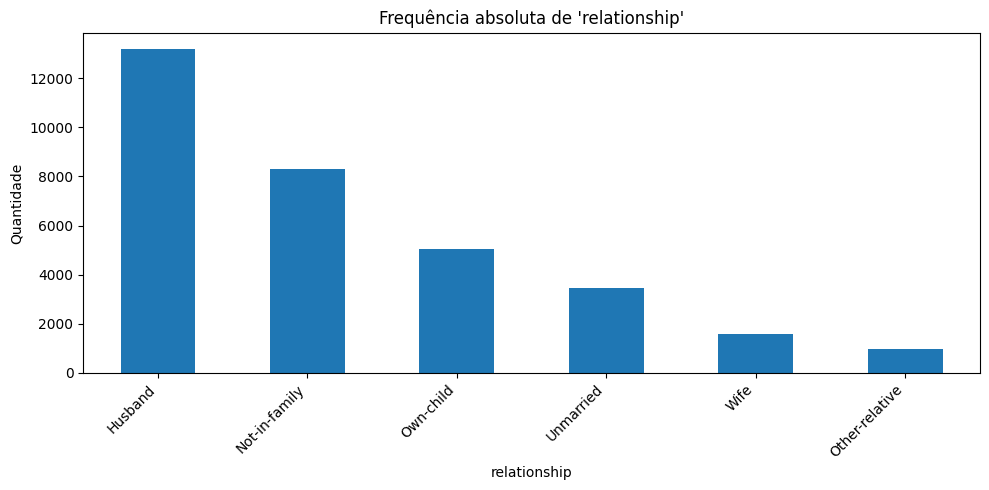


Variável 'race':
race
White                 27795
Black                  3122
Asian-Pac-Islander     1038
Amer-Indian-Eskimo      311
Other                   271
Name: count, dtype: int64


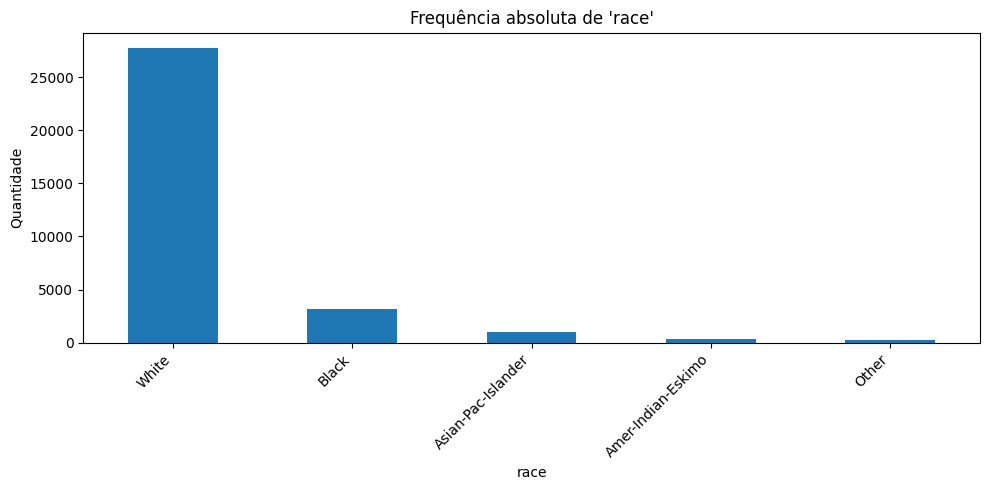


Variável 'sex':
sex
Male      21775
Female    10762
Name: count, dtype: int64


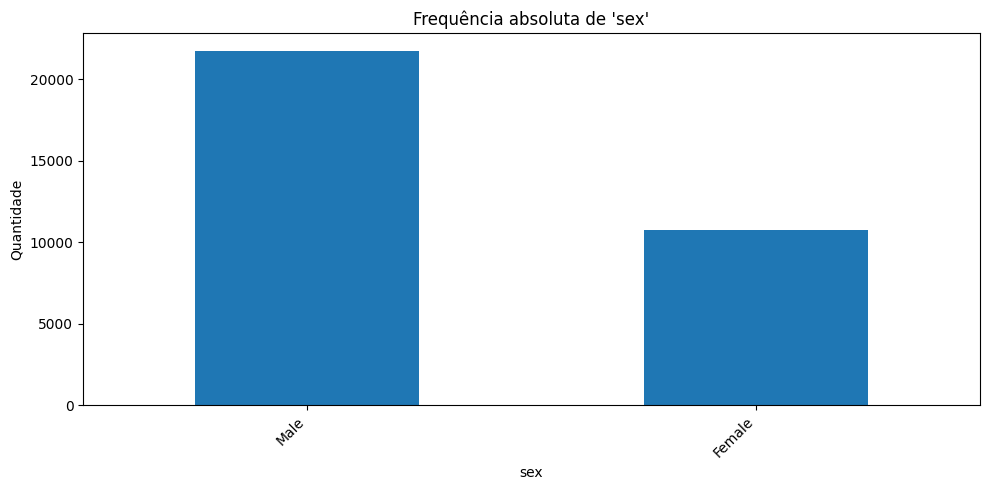


Variável 'native.country':
native.country
United-States                 29153
Mexico                          639
Desconhecido                    582
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            80
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Japan                            62
Guatemala                        62
Poland                           60
Columbia                         59
Taiwan                           51
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34
Peru                 

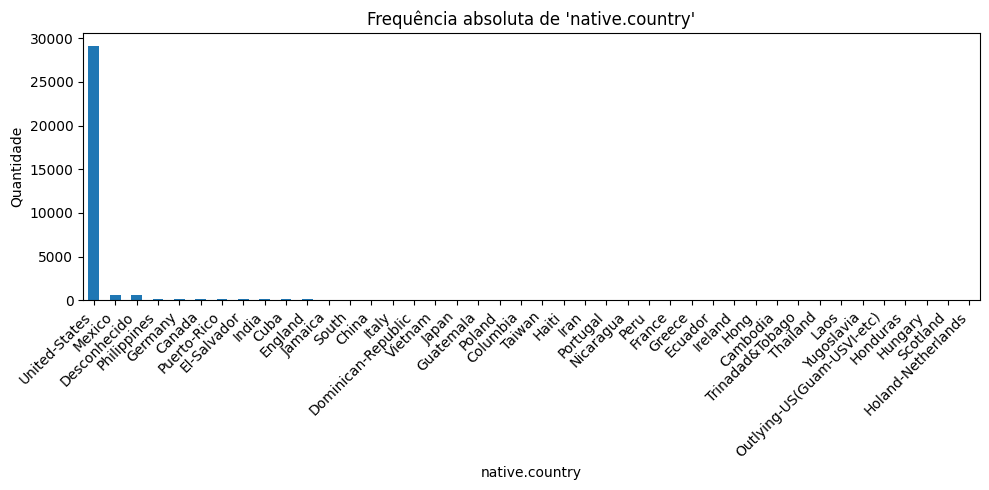


Variável 'income':
income
<=50K    24698
>50K      7839
Name: count, dtype: int64


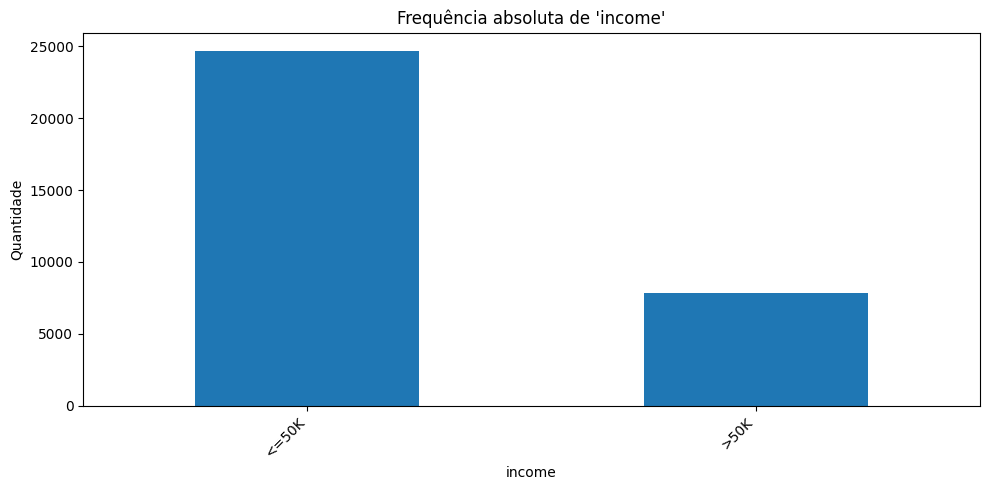


Frequência relativa:

Variável 'workclass' (%):
workclass
Private             0.70
Self-emp-not-inc    0.08
Local-gov           0.06
Desconhecido        0.06
State-gov           0.04
Self-emp-inc        0.03
Federal-gov         0.03
Without-pay         0.00
Never-worked        0.00
Name: proportion, dtype: float64

Variável 'workclass' (%):
workclass
Private             0.70
Self-emp-not-inc    0.08
Local-gov           0.06
Desconhecido        0.06
State-gov           0.04
Self-emp-inc        0.03
Federal-gov         0.03
Without-pay         0.00
Never-worked        0.00
Name: proportion, dtype: float64


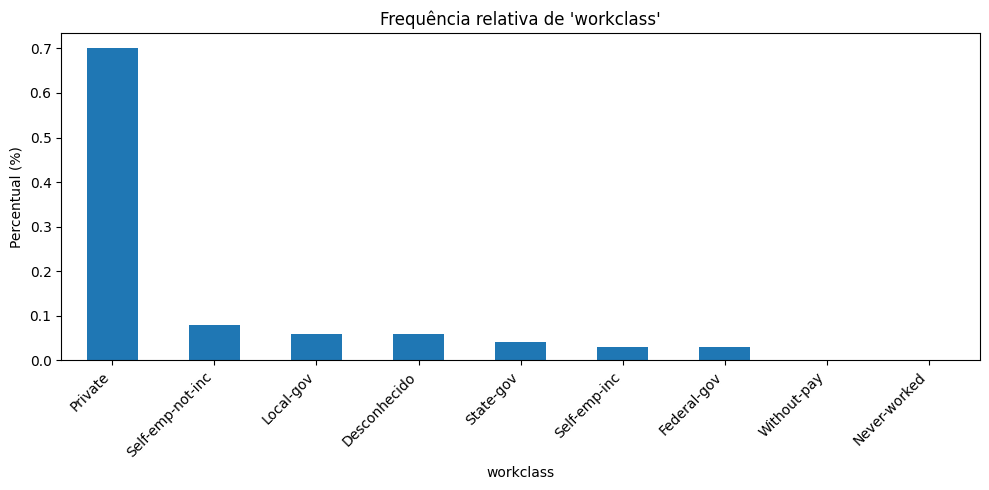


Variável 'education' (%):
education
HS-grad         0.32
Some-college    0.22
Bachelors       0.16
Masters         0.05
Assoc-voc       0.04
11th            0.04
Assoc-acdm      0.03
10th            0.03
7th-8th         0.02
Prof-school     0.02
9th             0.02
12th            0.01
Doctorate       0.01
5th-6th         0.01
1st-4th         0.01
Preschool       0.00
Name: proportion, dtype: float64

Variável 'education' (%):
education
HS-grad         0.32
Some-college    0.22
Bachelors       0.16
Masters         0.05
Assoc-voc       0.04
11th            0.04
Assoc-acdm      0.03
10th            0.03
7th-8th         0.02
Prof-school     0.02
9th             0.02
12th            0.01
Doctorate       0.01
5th-6th         0.01
1st-4th         0.01
Preschool       0.00
Name: proportion, dtype: float64


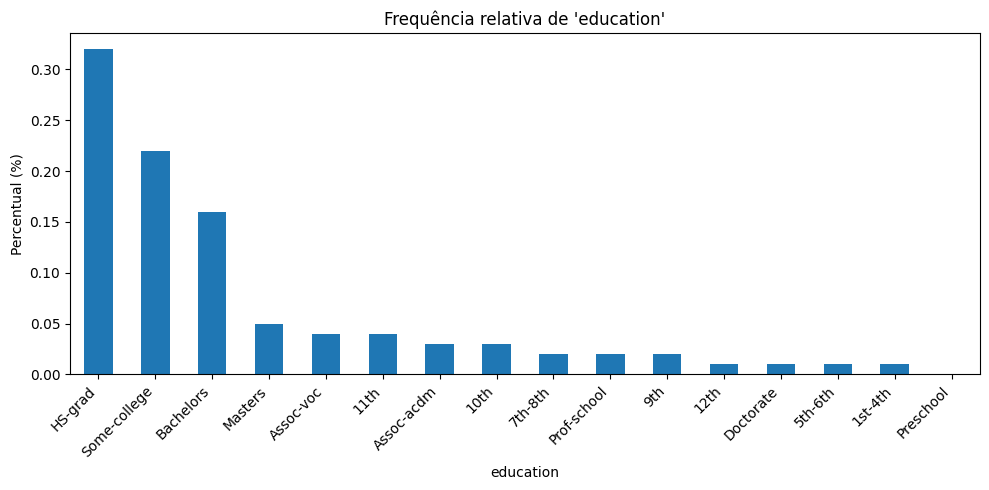


Variável 'marital.status' (%):
marital.status
Married-civ-spouse       0.46
Never-married            0.33
Divorced                 0.14
Separated                0.03
Widowed                  0.03
Married-spouse-absent    0.01
Married-AF-spouse        0.00
Name: proportion, dtype: float64

Variável 'marital.status' (%):
marital.status
Married-civ-spouse       0.46
Never-married            0.33
Divorced                 0.14
Separated                0.03
Widowed                  0.03
Married-spouse-absent    0.01
Married-AF-spouse        0.00
Name: proportion, dtype: float64


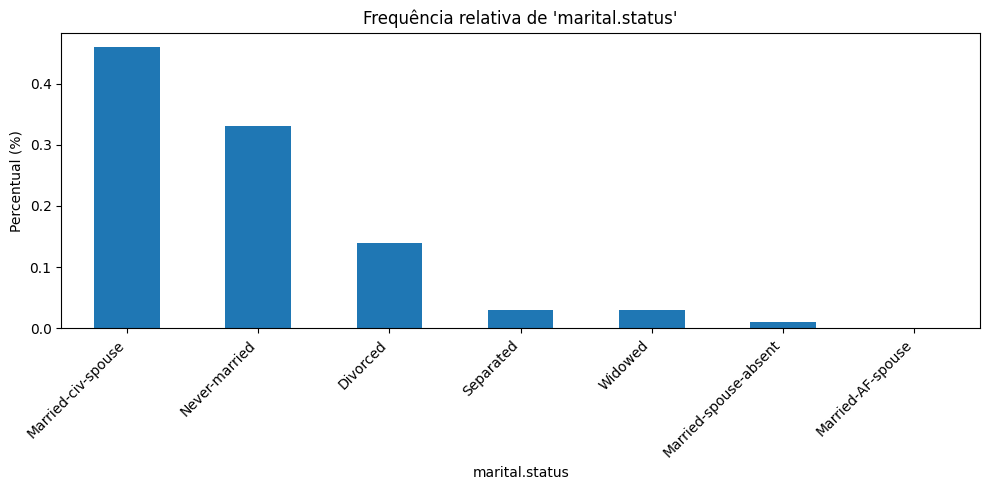


Variável 'occupation' (%):
occupation
Prof-specialty       0.13
Craft-repair         0.13
Exec-managerial      0.12
Adm-clerical         0.12
Sales                0.11
Other-service        0.10
Machine-op-inspct    0.06
Desconhecido         0.06
Transport-moving     0.05
Handlers-cleaners    0.04
Farming-fishing      0.03
Tech-support         0.03
Protective-serv      0.02
Priv-house-serv      0.00
Armed-Forces         0.00
Name: proportion, dtype: float64

Variável 'occupation' (%):
occupation
Prof-specialty       0.13
Craft-repair         0.13
Exec-managerial      0.12
Adm-clerical         0.12
Sales                0.11
Other-service        0.10
Machine-op-inspct    0.06
Desconhecido         0.06
Transport-moving     0.05
Handlers-cleaners    0.04
Farming-fishing      0.03
Tech-support         0.03
Protective-serv      0.02
Priv-house-serv      0.00
Armed-Forces         0.00
Name: proportion, dtype: float64


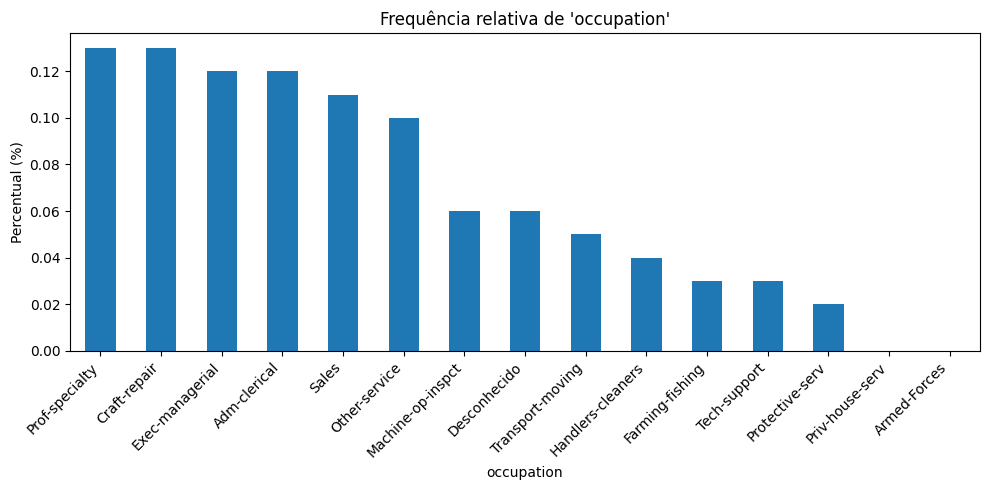


Variável 'relationship' (%):
relationship
Husband           0.41
Not-in-family     0.25
Own-child         0.16
Unmarried         0.11
Wife              0.05
Other-relative    0.03
Name: proportion, dtype: float64

Variável 'relationship' (%):
relationship
Husband           0.41
Not-in-family     0.25
Own-child         0.16
Unmarried         0.11
Wife              0.05
Other-relative    0.03
Name: proportion, dtype: float64


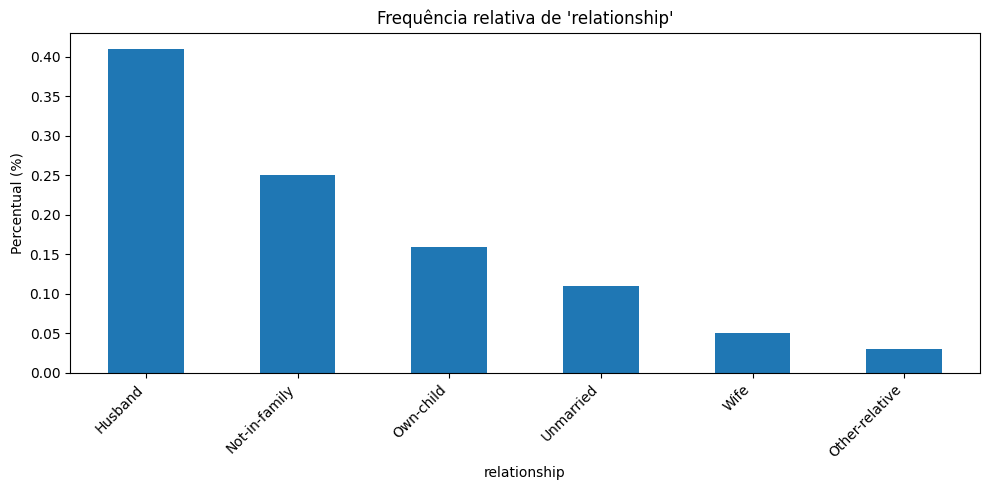


Variável 'race' (%):
race
White                 0.85
Black                 0.10
Asian-Pac-Islander    0.03
Amer-Indian-Eskimo    0.01
Other                 0.01
Name: proportion, dtype: float64

Variável 'race' (%):
race
White                 0.85
Black                 0.10
Asian-Pac-Islander    0.03
Amer-Indian-Eskimo    0.01
Other                 0.01
Name: proportion, dtype: float64


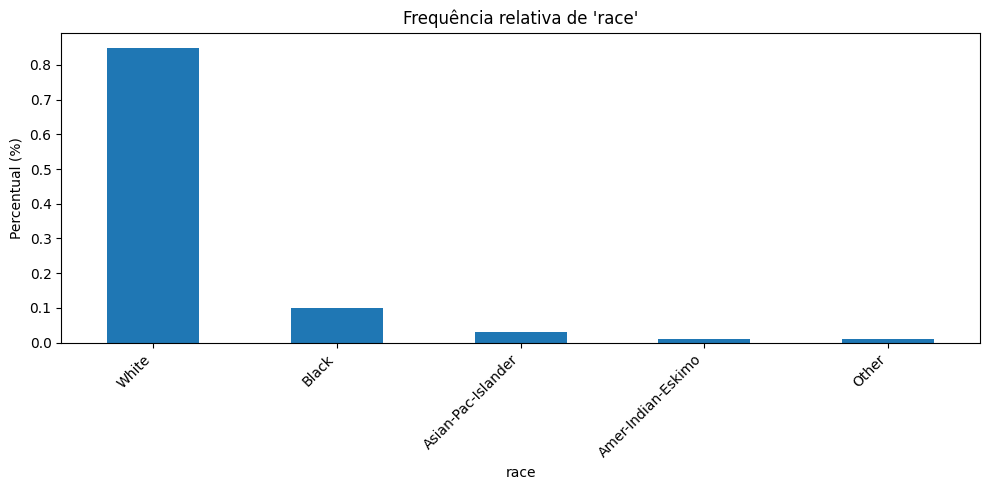


Variável 'sex' (%):
sex
Male      0.67
Female    0.33
Name: proportion, dtype: float64

Variável 'sex' (%):
sex
Male      0.67
Female    0.33
Name: proportion, dtype: float64


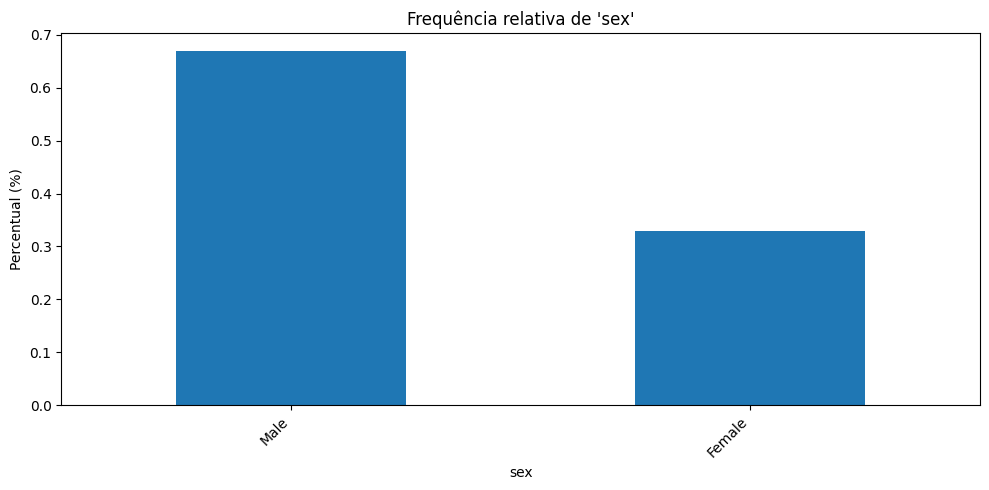


Variável 'native.country' (%):
native.country
United-States                 0.90
Mexico                        0.02
Desconhecido                  0.02
Philippines                   0.01
Germany                       0.00
Canada                        0.00
Puerto-Rico                   0.00
El-Salvador                   0.00
India                         0.00
Cuba                          0.00
England                       0.00
Jamaica                       0.00
South                         0.00
China                         0.00
Italy                         0.00
Dominican-Republic            0.00
Vietnam                       0.00
Japan                         0.00
Guatemala                     0.00
Poland                        0.00
Columbia                      0.00
Taiwan                        0.00
Haiti                         0.00
Iran                          0.00
Portugal                      0.00
Nicaragua                     0.00
Peru                          0.00
France  

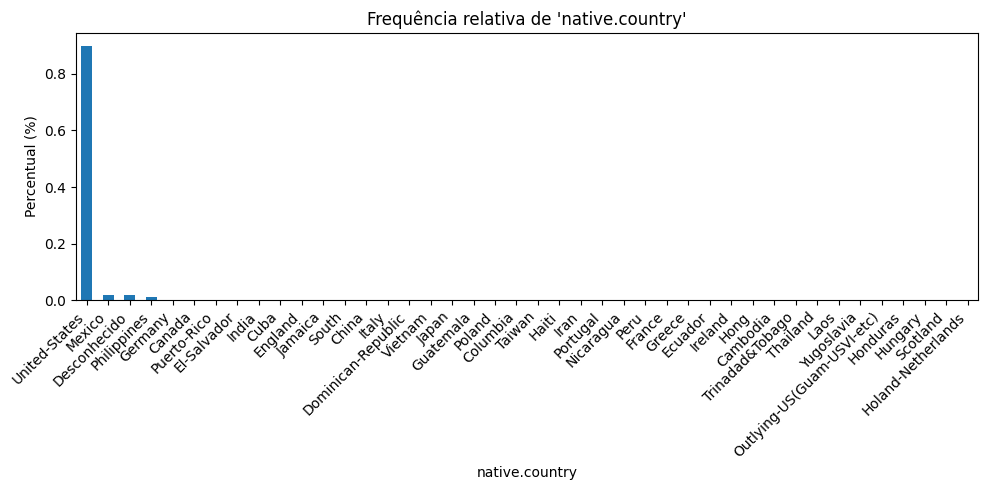


Variável 'income' (%):
income
<=50K    0.76
>50K     0.24
Name: proportion, dtype: float64

Variável 'income' (%):
income
<=50K    0.76
>50K     0.24
Name: proportion, dtype: float64


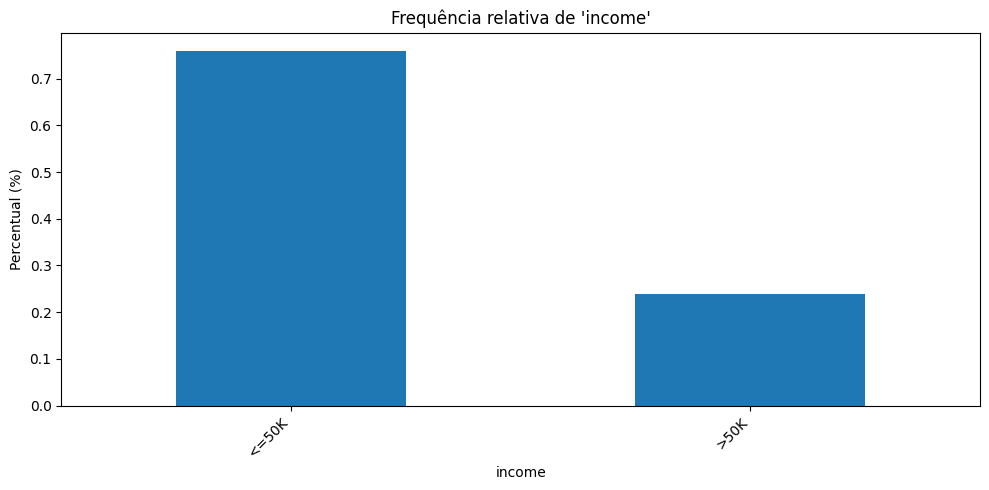



3. Categoria mais frequente:

Categoria mais frequente da variável 'workclass':
Categoria: Private
Quantidade: 22673
Percentual: 69.68%

Categoria mais frequente da variável 'education':
Categoria: HS-grad
Quantidade: 10494
Percentual: 32.25%

Categoria mais frequente da variável 'marital.status':
Categoria: Married-civ-spouse
Quantidade: 14970
Percentual: 46.01%

Categoria mais frequente da variável 'occupation':
Categoria: Prof-specialty
Quantidade: 4136
Percentual: 12.71%

Categoria mais frequente da variável 'relationship':
Categoria: Husband
Quantidade: 13187
Percentual: 40.53%

Categoria mais frequente da variável 'race':
Categoria: White
Quantidade: 27795
Percentual: 85.43%

Categoria mais frequente da variável 'sex':
Categoria: Male
Quantidade: 21775
Percentual: 66.92%

Categoria mais frequente da variável 'native.country':
Categoria: United-States
Quantidade: 29153
Percentual: 89.60%

Categoria mais frequente da variável 'income':
Categoria: <=50K
Quantidade: 24698
Percentua

In [ ]:
colunas_categoricas = ["workclass", "education", "marital.status", "occupation",
                        "relationship", "race", "sex", "native.country", "income"]
nivel_desequilibrio = 2

print("1. Quantidade de categorias:")
print("\nQuantidade de categorias únicas por variável:")
quantidade_categorias = df[colunas_categoricas].nunique()
print(quantidade_categorias)


print_formatado("2. Frequência absoluta e relativa:")

print("\nFrequência absoluta:")
for coluna in colunas_categoricas:
    frequencia_absoluta = df[coluna].value_counts(dropna=False)
    print(f"\nVariável '{coluna}':")
    print(frequencia_absoluta)

    plt.figure(figsize=(10, 5))

    frequencia_absoluta.plot(kind="bar")

    plt.title(f"Frequência absoluta de '{coluna}'")
    plt.xlabel(coluna)
    plt.ylabel("Quantidade")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

print("\nFrequência relativa:")
for coluna in colunas_categoricas:
    frequencia_relativa = (
        df[coluna]
        .value_counts(normalize=True, dropna=False)
        .round(2)
    )
    print(f"\nVariável '{coluna}' (%):")
    print(frequencia_relativa)

    print(f"\nVariável '{coluna}' (%):")
    print(frequencia_relativa.round(2))

    plt.figure(figsize=(10, 5))
    frequencia_relativa.plot(kind="bar")

    plt.title(f"Frequência relativa de '{coluna}'")
    plt.xlabel(coluna)
    plt.ylabel("Percentual (%)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


print_formatado("3. Categoria mais frequente:")
for coluna in colunas_categoricas:
    categoria_mais_frequente = df[coluna].mode(dropna=False)[0]
    quantidade = df[coluna].value_counts(dropna=False).iloc[0]

    percentual = (
        df[coluna]
        .value_counts(normalize=True, dropna=False)
        .iloc[0] * 100
    )

    print(f"\nCategoria mais frequente da variável '{coluna}':")
    print(f"Categoria: {categoria_mais_frequente}")
    print(f"Quantidade: {quantidade}")
    print(f"Percentual: {percentual:.2f}%")

# ignorar por enquanto
# print_formatado("4. Categorias raras:")
# limite_categoria_rara = 0.01
# for coluna in colunas_categoricas:
#     frequencia_relativa = df[coluna].value_counts(
#         normalize=True,
#         dropna=False
#     )

#     categorias_raras = frequencia_relativa[
#         frequencia_relativa < limite_categoria_rara
#     ]

#     print(f"\nCategorias raras da variável '{coluna}':")

#     if categorias_raras.empty:
#         print("Nenhuma categoria rara encontrada.")
#     else:
#         print((categorias_raras * 100).round(2).astype(str) + "%")


# print_formatado("5. Possível desiquilíbrio entre classes:")
# for coluna in colunas_categoricas:
#     contagem = df[coluna].value_counts(dropna=False)

#     maior_frequencia = contagem.max()
#     menor_frequencia = contagem.min()
#     razao_desequilibrio = maior_frequencia / menor_frequencia

#     print(f"\nVariável '{coluna}':")
#     print(f"Maior frequência: {maior_frequencia}")
#     print(f"Menor frequência: {menor_frequencia}")
#     print(f"Razão maior/menor frequência: {razao_desequilibrio:.2f}")

#     if razao_desequilibrio >= nivel_desequilibrio:
#         print("Conclusão: Possível desequilíbrio.")
#     else:
#         print("Conclusão: Sem desequilíbrio.")

# **Análise Multivariada**

## **Variáveis numéricas**



1. Correlação linear entre alvo x independentes:

Correlações entre variáveis independentes e alvo:
education.num x income: r = 0.335 (positiva)
age x income: r = 0.234 (positiva)
hours.per.week x income: r = 0.230 (positiva)
capital.gain x income: r = 0.223 (positiva)
capital.loss x income: r = 0.151 (positiva)
fnlwgt x income: r = -0.010 (negativa)


2. Correlação linear entre variáveis independentes:

Matriz de correlação variáveis independentes:
                  age  fnlwgt  education.num  capital.gain  capital.loss  \
age             1.000  -0.076          0.036         0.078         0.058   
fnlwgt         -0.076   1.000         -0.043         0.000        -0.010   
education.num   0.036  -0.043          1.000         0.123         0.080   
capital.gain    0.078   0.000          0.123         1.000        -0.032   
capital.loss    0.058  -0.010          0.080        -0.032         1.000   
hours.per.week  0.069  -0.019          0.148         0.078         0.054   

           

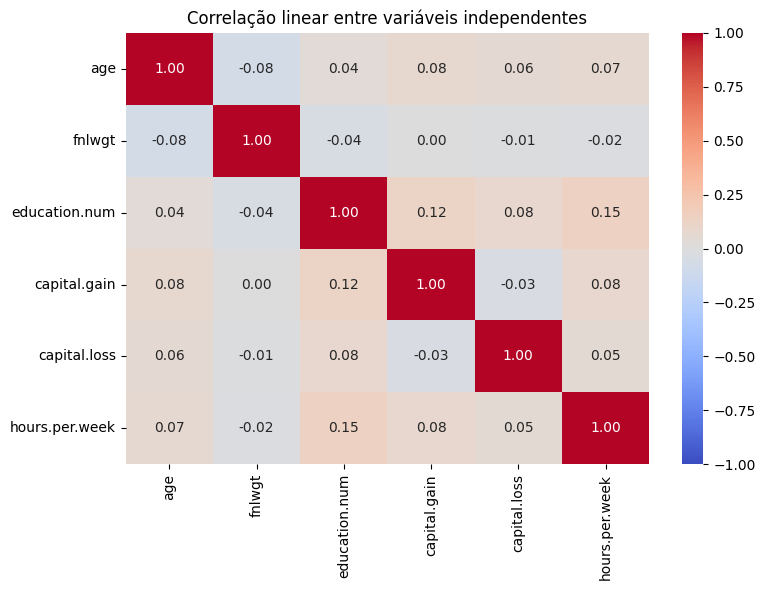


Pares ordenados pela maior correlação absoluta:
education.num x hours.per.week: r = 0.148 (positiva)
education.num x capital.gain: r = 0.123 (positiva)
education.num x capital.loss: r = 0.080 (positiva)
capital.gain x hours.per.week: r = 0.078 (positiva)
age x capital.gain: r = 0.078 (positiva)
age x fnlwgt: r = -0.076 (negativa)
age x hours.per.week: r = 0.069 (positiva)
age x capital.loss: r = 0.058 (positiva)
capital.loss x hours.per.week: r = 0.054 (positiva)
fnlwgt x education.num: r = -0.043 (negativa)
age x education.num: r = 0.036 (positiva)
capital.gain x capital.loss: r = -0.032 (negativa)
fnlwgt x hours.per.week: r = -0.019 (negativa)
fnlwgt x capital.loss: r = -0.010 (negativa)
fnlwgt x capital.gain: r = 0.000 (positiva)


3. Correlação não-linear entre alvo x independentes:
education.num x income: ρ = 0.330 (positiva)
capital.gain x income: ρ = 0.278 (positiva)
age x income: ρ = 0.273 (positiva)
hours.per.week x income: ρ = 0.269 (positiva)
capital.loss x income: ρ = 0.14

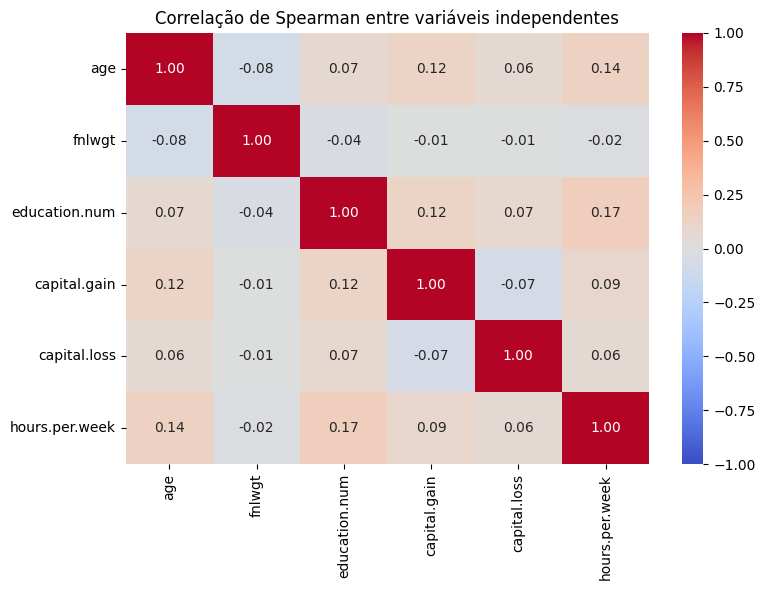


Pares ordenados pela maior correlação absoluta:
education.num x hours.per.week: ρ = 0.167 (positiva)
age x hours.per.week: ρ = 0.143 (positiva)
age x capital.gain: ρ = 0.125 (positiva)
education.num x capital.gain: ρ = 0.119 (positiva)
capital.gain x hours.per.week: ρ = 0.093 (positiva)
age x fnlwgt: ρ = -0.078 (negativa)
education.num x capital.loss: ρ = 0.075 (positiva)
capital.gain x capital.loss: ρ = -0.067 (negativa)
age x education.num: ρ = 0.066 (positiva)
capital.loss x hours.per.week: ρ = 0.060 (positiva)
age x capital.loss: ρ = 0.058 (positiva)
fnlwgt x education.num: ρ = -0.036 (negativa)
fnlwgt x hours.per.week: ρ = -0.022 (negativa)
fnlwgt x capital.loss: ρ = -0.007 (negativa)
fnlwgt x capital.gain: ρ = -0.006 (negativa)


In [ ]:
print_formatado("1. Correlação linear entre alvo x independentes:")
df["income_binaria"] = df["income"].astype("string").str.strip().str.replace(".", "", regex=False).map({"<=50K": 0, ">50K": 1})
correlacoes_alvo = df[colunas_numericas].corrwith(df["income_binaria"], method="pearson").sort_values(ascending=False) # linhas importante

print("\nCorrelações entre variáveis independentes e alvo:")
for coluna, valor in correlacoes_alvo.items():
    sinal = "positiva" if valor > 0 else ("negativa" if valor < 0 else "nula")
    print(f"{coluna} x income: r = {valor:.3f} ({sinal})")

print_formatado("2. Correlação linear entre variáveis independentes:")
matriz_corr_independentes = df[colunas_numericas].corr(method="pearson")    # linhas importante

pares_corr = []
for var1, var2 in combinations(colunas_numericas, 2):
    pares_corr.append((var1, var2, matriz_corr_independentes.loc[var1, var2]))
pares_corr = sorted(pares_corr, key=lambda x: abs(x[2]), reverse=True)

print("\nMatriz de correlação variáveis independentes:")
print(matriz_corr_independentes.round(3))

print("\nHeatmap:")
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr_independentes, annot=True, fmt=".2f", vmin=-1, vmax=1, cmap="coolwarm")
plt.title("Correlação linear entre variáveis independentes")
plt.tight_layout()
plt.show()

print("\nPares ordenados pela maior correlação absoluta:")
for var1, var2, valor in pares_corr:
    sinal = "positiva" if valor > 0 else ("negativa" if valor < 0 else "nula")
    print(f"{var1} x {var2}: r = {valor:.3f} ({sinal})")

print_formatado("3. Correlação não-linear entre alvo x independentes:")
df["income_binaria"] = df["income"].astype("string").str.strip().str.replace(".", "", regex=False).map({"<=50K": 0, ">50K": 1})
correlacoes_spearman = df[colunas_numericas].corrwith(df["income_binaria"], method="spearman").sort_values(ascending=False)
for coluna, valor in correlacoes_spearman.items():
    sinal = "positiva" if valor > 0 else ("negativa" if valor < 0 else "nula")
    print(f"{coluna} x income: ρ = {valor:.3f} ({sinal})")


print_formatado("4. Correlação não-linear entre variáveis independentes:")

print("\nMatriz de correlação de Spearman:")
matriz_spearman_independentes = df[colunas_numericas].corr(method="spearman")
print(matriz_spearman_independentes.round(3))

print("\nHeatmat:")
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_spearman_independentes, annot=True, fmt=".2f", vmin=-1, vmax=1, cmap="coolwarm")
plt.title("Correlação de Spearman entre variáveis independentes")
plt.tight_layout()
plt.show()

print("\nPares ordenados pela maior correlação absoluta:")
pares_spearman = []
for var1, var2 in combinations(colunas_numericas, 2):
    pares_spearman.append((var1, var2, matriz_spearman_independentes.loc[var1, var2]))
pares_spearman = sorted(pares_spearman, key=lambda x: abs(x[2]), reverse=True)
for var1, var2, valor in pares_spearman:
    sinal = "positiva" if valor > 0 else ("negativa" if valor < 0 else "nula")
    print(f"{var1} x {var2}: ρ = {valor:.3f} ({sinal})")

### **Observações da Análise Multivariada - Variáveis Numéricas**

### 1. Correlação linear entre alvo x independentes

* `education.num`: apresentou a maior correlação linear com `income`, com `r = 0,335`, indicando uma correlação positiva moderada. Isso sugere que níveis mais altos de escolaridade tendem a estar associados à classe de renda `>50K`.

* `age`: apresentou correlação positiva fraca com `income`, com `r = 0,234`. Indivíduos mais velhos tendem a estar associados com maior frequência à classe de renda `>50K`, embora essa relação linear não seja forte.

* `hours.per.week`: apresentou correlação positiva fraca com `income`, com `r = 0,230`. Isso indica que uma maior quantidade de horas trabalhadas por semana tende a estar associada à classe de renda `>50K`.

* `capital.gain`: apresentou correlação positiva fraca com `income`, com `r = 0,223`. Valores maiores de ganho de capital tendem a estar associados à classe de renda `>50K`.

* `capital.loss`: apresentou correlação positiva fraca com `income`, com `r = 0,151`, indicando uma pequena associação linear com a classe de maior renda.

* `fnlwgt`: apresentou correlação praticamente nula com `income`, com `r = -0,010`. Esse resultado indica que o peso amostral não possui relação linear relevante com a variável alvo.

* Nenhuma variável numérica apresentou correlação linear forte ou muito forte com `income`.

* `education.num` foi a variável numérica com maior associação linear com o alvo, seguida por `age`, `hours.per.week` e `capital.gain`.

### 2. Correlação linear entre variáveis independentes

* As correlações entre as variáveis numéricas independentes foram, em geral, muito fracas, com valores próximos de zero.

* A maior correlação observada foi entre `education.num` e `hours.per.week`, com `r = 0,148`, indicando uma relação linear positiva fraca. Isso sugere que níveis educacionais mais altos tendem a estar associados a uma quantidade ligeiramente maior de horas trabalhadas por semana.

* A relação entre `education.num` e `capital.gain` apresentou `r = 0,123`, também indicando uma correlação positiva fraca.

* As correlações entre `education.num` e `capital.loss` (`r = 0,080`), `capital.gain` e `hours.per.week` (`r = 0,078`) e `age` e `capital.gain` (`r = 0,078`) foram muito fracas.

* A variável `age` apresentou correlação negativa muito fraca com `fnlwgt`, com `r = -0,076`, indicando que o aumento da idade está associado a uma redução mínima no peso amostral.

* As correlações entre `age` e `hours.per.week` (`r = 0,069`), `age` e `capital.loss` (`r = 0,058`) e `capital.loss` e `hours.per.week` (`r = 0,054`) foram positivas, porém muito fracas.

* A variável `fnlwgt` apresentou correlações próximas de zero com todas as demais variáveis numéricas, incluindo `capital.gain` (`r = 0,000`), `capital.loss` (`r = -0,010`) e `hours.per.week` (`r = -0,019`).

* A correlação entre `capital.gain` e `capital.loss` foi negativa e muito fraca, com `r = -0,032`, indicando que praticamente não existe relação linear entre essas duas variáveis.

* Nenhum par de variáveis apresentou correlação forte ou muito forte, considerando como referência valores absolutos superiores a `0,70`.

* Também não foram identificadas correlações absolutas superiores a `0,80`, o que indica ausência de sinais relevantes de redundância linear ou multicolinearidade forte entre as variáveis numéricas independentes.

### 3. Correlação não linear entre alvo x independentes

* `education.num`: maior correlação de Spearman com `income`, com `ρ = 0,330`, indicando uma associação positiva moderada. Isso sugere que níveis mais altos de escolaridade tendem a estar associados à classe de renda `>50K`.

* `capital.gain`: correlação positiva fraca com `income`, com `ρ = 0,278`. Valores maiores de ganho de capital tendem a estar associados à classe de renda `>50K`.

* `age`: correlação positiva fraca com `income`, com `ρ = 0,273`. Indivíduos com idades mais elevadas tendem a apresentar maior associação com renda superior a `50K`.

* `hours.per.week`: correlação positiva fraca com `income`, com `ρ = 0,269`. Isso indica que maiores cargas de trabalho semanais tendem a estar associadas à classe de maior renda.

* `capital.loss`: correlação positiva fraca com `income`, com `ρ = 0,141`, indicando uma pequena associação monotônica com a classe `>50K`.

* `fnlwgt`: correlação praticamente nula com `income`, com `ρ = -0,011`. Esse resultado indica que o peso amostral não possui relação monotônica relevante com a variável alvo.

* Nenhuma variável numérica apresentou correlação monotônica forte ou muito forte com `income`.

* `education.num` foi a variável numérica com maior associação monotônica com o alvo, seguida por **`capital.gain`**, **`age`** e **`hours.per.week`**.

* Os valores de Spearman de **`capital.gain`**, **`age`** e **`hours.per.week`** foram superiores aos respectivos valores de Pearson, sugerindo que essas relações podem ser monotônicas, mas não perfeitamente lineares.


### 4. Correlação não linear entre variáveis independentes

* As correlações de Spearman entre as variáveis numéricas independentes foram, em geral, muito fracas, com valores próximos de zero.

* A maior correlação observada foi entre `education.num` e `hours.per.week`, com `ρ = 0,167`, indicando uma associação monotônica positiva fraca. Isso sugere que níveis mais altos de escolaridade tendem a estar associados a uma quantidade ligeiramente maior de horas trabalhadas por semana.

* A relação entre `age` e `hours.per.week` apresentou `ρ = 0,143`, indicando uma associação monotônica positiva fraca. Indivíduos com idades mais elevadas tendem a apresentar cargas horárias semanais ligeiramente maiores.

* A correlação entre `age` e `capital.gain` foi positiva e fraca, com `ρ = 0,125`, sugerindo que o aumento da idade tende a estar associado a valores um pouco maiores de ganho de capital.

* A relação entre `education.num` e `capital.gain` apresentou `ρ = 0,119`, também indicando uma associação monotônica positiva fraca.

* As correlações entre `capital.gain` e `hours.per.week` (`ρ = 0,093`), `education.num` e `capital.loss` (`ρ = 0,075`) e `age` e `education.num` (`ρ = 0,066`) foram positivas, porém muito fracas.

* A variável `age` apresentou correlação negativa muito fraca com `fnlwgt`, com `ρ = -0,078`, indicando uma tendência praticamente desprezível de redução do peso amostral à medida que a idade aumenta.

* A correlação entre `capital.gain` e `capital.loss` foi negativa e muito fraca, com `ρ = -0,067`, indicando ausência de uma associação monotônica relevante entre ganhos e perdas de capital.

* A variável `fnlwgt` apresentou correlações próximas de zero com todas as demais variáveis numéricas, incluindo `capital.gain` (`ρ = -0,006`), `capital.loss` (`ρ = -0,007`) e `hours.per.week` (`ρ = -0,022`).

* Nenhum par de variáveis apresentou correlação monotônica forte ou muito forte.

* Também não foram identificadas correlações absolutas superiores a `0,80`, indicando ausência de sinais relevantes de redundância monotônica entre as variáveis numéricas independentes.

* Em comparação com Pearson, algumas relações, como `age` com `hours.per.week` e `age` com `capital.gain`, apresentaram valores de Spearman ligeiramente maiores, sugerindo que essas associações podem ser monotônicas, mas não perfeitamente lineares.

* Não há justificativa para remover variáveis numéricas com base apenas nessa matriz de correlação de Spearman.

* Correlações de Spearman próximas de zero indicam ausência de relação monotônica relevante, mas não descartam relações não monotônicas, como padrões em formato de U.

### 5. Analisar variáveis preditoras

* `education.num` foi a variável numérica com maior associação com `income` tanto na correlação de Pearson (`r = 0,335`) quanto na correlação de Spearman (`ρ = 0,330`).

* A proximidade entre os valores de Pearson e Spearman indica que a relação entre `education.num` e `income` é predominantemente monotônica e aproximadamente linear.

* Dessa forma, `education.num` apresenta o maior potencial preditivo individual entre as variáveis numéricas analisadas.

* `age` apresentou correlação positiva com `income` tanto em Pearson (`r = 0,234`) quanto em Spearman (`ρ = 0,273`).

* O valor de Spearman ligeiramente superior ao de Pearson sugere que a relação entre `age` e `income` pode ser monotônica, mas não perfeitamente linear.

* `hours.per.week` também apresentou associação positiva com o alvo, com Pearson igual a `0,230` e Spearman igual a `0,269`.

* Esse resultado indica que `hours.per.week` possui potencial preditivo, embora sua relação com a renda possa apresentar variações não lineares ou efeitos de faixas específicas de carga horária.

* `capital.gain` apresentou Pearson igual a `0,223` e Spearman igual a `0,278`.

* A diferença entre os dois coeficientes sugere que `capital.gain` possui uma relação monotônica com `income` mais forte do que sua relação estritamente linear.

* Esse comportamento pode ocorrer porque `capital.gain` possui grande concentração de valores iguais a zero e poucos valores positivos elevados.

* Mesmo com correlação moderada ou fraca, `capital.gain` pode ser uma variável preditora importante, especialmente para identificar indivíduos pertencentes à classe `>50K`.

* `capital.loss` apresentou associações mais fracas com o alvo, com Pearson igual a `0,151` e Spearman igual a `0,141`.

* Apesar de seu potencial preditivo individual ser menor, `capital.loss` ainda pode contribuir para o modelo em conjunto com outras variáveis.

* `fnlwgt` apresentou correlação praticamente nula com `income`, tanto em Pearson (`r = -0,010`) quanto em Spearman (`ρ = -0,011`).

* Esses resultados indicam que `fnlwgt` possui pouco ou nenhum potencial preditivo individual para a variável alvo.

* Além disso, `fnlwgt` representa um peso amostral do censo, e não uma característica socioeconômica direta do indivíduo.

* Por esse motivo, `fnlwgt` é a principal candidata a ser retirada do conjunto de variáveis preditoras, desde que sua exclusão seja confirmada por meio da avaliação do desempenho do modelo.

### 6. Analisar e tratar variáveis redundantes

* As correlações de Pearson e Spearman entre as variáveis numéricas independentes foram muito baixas.

* A maior correlação de Pearson foi observada entre `education.num` e `hours.per.week`, com `r = 0,148`.

* A maior correlação de Spearman também ocorreu entre `education.num` e `hours.per.week`, com `ρ = 0,167`.

* Esses valores são baixos e indicam que as duas variáveis apresentam pouca sobreposição de informação.

* As relações entre `age` e `hours.per.week`, `age` e `capital.gain` e `education.num` e `capital.gain` também foram fracas.

* Nenhum par apresentou correlação absoluta próxima de `0,70` ou `0,80`, valores geralmente utilizados como sinais de possível redundância ou multicolinearidade elevada.

* Dessa forma, a decisão é não remover qualquer variável do conjunto de dados, pois não este forte redundância entre as variáveis.



## **Variáveis categóricas**

In [ ]:
colunas_categoricas = ["workclass", "education", "marital.status", "occupation",
                        "relationship", "race", "sex", "native.country", "income"]

print_formatado("1. Associação entre alvo x independentes:")
for coluna in colunas_categoricas:
    print(f"\n{coluna} x income:")

    print("\nTabela de contingência:")
    tabela_contingencia = pd.crosstab(df[coluna], df["income"])
    print(tabela_contingencia)

    print("\nTeste Qui-quadrado:")
    chi2, p_valor, graus_liberdade, frequencias_esperadas = chi2_contingency(tabela_contingencia)
    print(f"χ² = {chi2:.3f}")
    print(f"P-valor = {p_valor:.5f}")
    print(f"Graus de liberdade = {graus_liberdade}")

    print("\nV de Cramér:")
    n = tabela_contingencia.to_numpy().sum()
    menor_dimensao = min(tabela_contingencia.shape[0] - 1, tabela_contingencia.shape[1] - 1)
    v_cramer = np.sqrt(chi2 / (n * menor_dimensao)) if menor_dimensao > 0 else np.nan
    print(f"V de Cramér = {v_cramer:.3f}")

print_formatado("2. Associação entre variáveis independentes:")
for coluna_1, coluna_2 in combinations(colunas_categoricas, 2):

    print(f"\n{coluna_1} x {coluna_2}:")

    print("\nTabela de contingência:")
    tabela_contingencia = pd.crosstab(df[coluna_1], df[coluna_2])
    print(tabela_contingencia)

    print("\nTeste Qui-quadrado:")
    chi2, p_valor, graus_liberdade, frequencias_esperadas = chi2_contingency(tabela_contingencia)
    print(f"χ² = {chi2:.3f}")
    print(f"P-valor = {p_valor:.5f}")
    print(f"Graus de liberdade = {graus_liberdade}")

    print("\nV de Cramér:")
    n = tabela_contingencia.to_numpy().sum()
    menor_dimensao = min(tabela_contingencia.shape[0] - 1, tabela_contingencia.shape[1] - 1)
    v_cramer = np.sqrt(chi2 / (n * menor_dimensao)) if menor_dimensao > 0 else np.nan
    print(f"V de Cramér = {v_cramer:.3f}")



1. Associação entre alvo x independentes:

workclass x income:

Tabela de contingência:
income            <=50K  >50K
workclass                    
Desconhecido       1645   191
Federal-gov         589   371
Local-gov          1476   617
Never-worked          7     0
Private           17712  4961
Self-emp-inc        494   622
Self-emp-not-inc   1816   724
State-gov           945   353
Without-pay          14     0

Teste Qui-quadrado:
χ² = 1044.696
P-valor = 0.00000
Graus de liberdade = 8

V de Cramér:
V de Cramér = 0.179

education x income:

Tabela de contingência:
income        <=50K  >50K
education                
10th            871    62
11th           1115    60
12th            400    33
1st-4th         160     6
5th-6th         316    16
7th-8th         605    40
9th             487    27
Assoc-acdm      802   265
Assoc-voc      1021   361
Bachelors      3132  2221
Doctorate       107   306
HS-grad        8820  1674
Masters         763   959
Preschool        50     0
Prof-sch

### **Observações da Análise de Associação entre Variáveis Categóricas**

### 1. Associação entre alvo x variáveis independentes

* Todas as variáveis categóricas apresentaram `p-valor < 0,05` no teste qui-quadrado, indicando associação estatisticamente significativa com `income`.

* Como a base possui muitas observações, o p-valor deve ser analisado em conjunto com o V de Cramér, que indica a intensidade da associação.

* `relationship` apresentou a maior associação com `income`, com `V de Cramér = 0,454`, seguida por `marital.status`, com `V = 0,447`. Ambas apresentaram associação moderada e elevado potencial preditivo.

* `education` (`V = 0,369`) e `occupation` (`V = 0,352`) também apresentaram associações moderadas com o alvo, indicando potencial preditivo relevante.

* `sex` (`V = 0,216`) e `workclass` (`V = 0,179`) apresentaram associações fracas, mas ainda podem contribuir para o modelo em conjunto com outras variáveis.

* `race` (`V = 0,101`) apresentou associação fraca, enquanto `native.country` (`V = 0,098`) apresentou associação muito fraca com `income`.

* Em ordem decrescente de associação com o alvo, as variáveis foram: `relationship`, `marital.status`, `education`, `occupation`, `sex`, `workclass`, `race` e `native.country`.

* Nenhuma variável categórica independente apresentou associação forte ou muito forte com `income`.

* `relationship` e `marital.status` representam informações familiares semelhantes, sendo recomendável avaliar a associação entre elas para identificar possível redundância.

* `native.country` possui muitas categorias com poucas observações, o que pode comprometer as condições do teste qui-quadrado. Pode ser necessário agrupar categorias raras em `Outros`.

* O resultado `income x income`, com `V de Cramér = 1,000`, deve ser desconsiderado, pois representa a associação da variável-alvo com ela mesma. A variável `income` deve ser removida de `colunas_categoricas`.

* Uma associação fraca não significa necessariamente que a variável seja irrelevante, pois ela pode contribuir por meio de interações com outras variáveis.

* Associação estatística não implica relação de causa e efeito.

## **Observações da Análise de Associação entre Variáveis Categóricas**

### 2. Associação entre variáveis independentes

* Todos os pares analisados apresentaram `p-valor < 0,05`, indicando associação estatisticamente significativa. Entretanto, devido ao tamanho elevado da amostra, a intensidade deve ser avaliada principalmente pelo V de Cramér.

* A maior associação ocorreu entre `relationship` e `sex`, com `V de Cramér = 0,649`, indicando associação forte. Esse resultado ocorre porque categorias como `Husband` e `Wife` estão diretamente relacionadas ao sexo registrado, sugerindo elevada sobreposição de informação.

* `marital.status` e `relationship` apresentaram `V = 0,488`, indicando associação moderada próxima de forte. Como ambas representam aspectos da situação familiar, podem conter informações redundantes.

* `marital.status` e `sex` apresentaram associação moderada, com `V = 0,462`, enquanto `occupation` e `sex` apresentaram `V = 0,424`. Esses resultados mostram diferenças relevantes na distribuição do estado civil e das ocupações entre homens e mulheres.

* `race` e `native.country` apresentaram associação moderada, com `V = 0,409`. Essa relação deve ser interpretada com cautela, pois `native.country` possui muitas categorias com poucas observações.

* `workclass` e `occupation` apresentaram `V = 0,400`, indicando associação moderada. Isso é esperado, pois determinadas ocupações estão concentradas em tipos específicos de vínculo profissional.

* Os demais pares apresentaram associações fracas ou muito fracas, indicando pouca sobreposição de informação entre a maioria das variáveis categóricas.

* Os principais pares que devem ser investigados por possível redundância são `relationship` x `sex`, `marital.status` x `relationship`, `marital.status` x `sex`, `occupation` x `sex`, `race` x `native.country` e `workclass` x `occupation`.

* Uma associação elevada não determina automaticamente a remoção de uma variável. A decisão deve considerar o significado das variáveis, o desempenho do modelo e técnicas como importância das variáveis ou seleção de atributos.

* Os resultados envolvendo `income` devem ser desconsiderados nesta etapa, pois `income` é a variável-alvo e não uma variável independente. Ela deve ser removida da lista utilizada para gerar as combinações.

* Associação estatística entre as variáveis não implica relação de causa e efeito.

### 3. Analisar variáveis preditoras

* **`relationship` (`V = 0,454`) e `marital.status` (`V = 0,447`) apresentaram o maior potencial preditivo entre as variáveis categóricas.**

* `education` (`V = 0,369`) e `occupation` (`V = 0,352`) também apresentaram associações moderadas e são relevantes para a modelagem.

* `sex` (`V = 0,216`) e `workclass` (`V = 0,179`) apresentaram associações fracas, mas ainda podem contribuir em conjunto com outras variáveis.

* `race` (`V = 0,101`) e `native.country` (`V = 0,098`) apresentaram o menor potencial preditivo individual.

* `relationship`, `marital.status` e `sex` podem conter informações parcialmente redundantes, devendo ser comparadas durante a seleção de variáveis.

### 4. Analisar e tratar variáveis redundantes

* `relationship` e `sex` apresentaram a maior associação, com `V = 0,649`, indicando forte sobreposição de informação. Decisão é testar a remoção de `sex`, mantendo `relationship`.

* `marital.status` e `relationship` apresentaram associação moderada próxima de forte, com `V = 0,488`, indicando possível redundância parcial entre informações familiares.

* `occupation` e `sex`, `race` e `native.country`, além de `workclass` e `occupation`, apresentaram associações moderadas, mas representam conceitos diferentes e não devem ser removidas apenas com base no V de Cramér.

* O principal grupo a ser investigado por redundância é formado por `relationship`, `marital.status` e `sex`.

* A remoção definitiva deve ser confirmada comparando modelos com e sem essas variáveis. Caso o desempenho permaneça semelhante, a variável retirada pode ser considerada redundante.


# **Identificação de Outliers e Anomalias**

## **Variáveis numéricas**



1. Selecionar método de identificação de outlier:


1.1. Q-Q Plot, Assimetria, Shapiro-Wilk

Variável age:


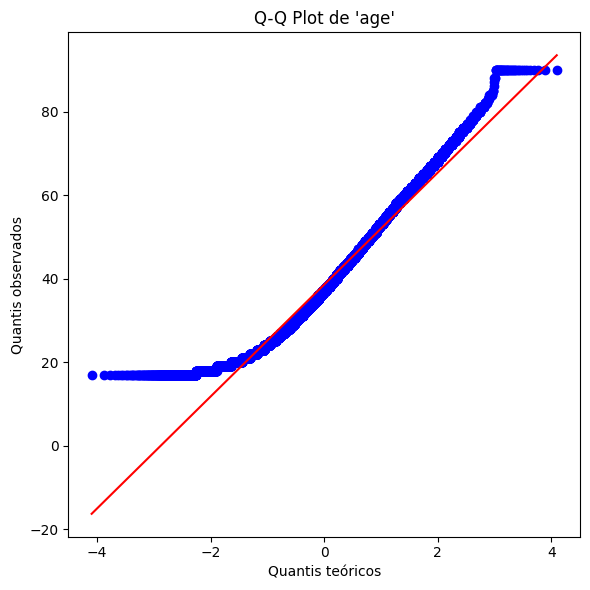

Assimetria             : 0.5576631514973125
Teste Shapiro-Wilk, p-valor:2.792320176551868e-32

Variável fnlwgt:


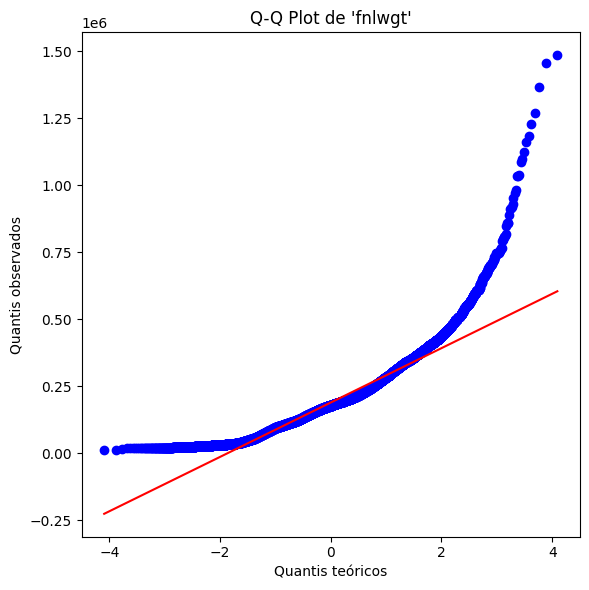

Assimetria             : 1.4477029083495343
Teste Shapiro-Wilk, p-valor:2.227353270769972e-44

Variável education.num:


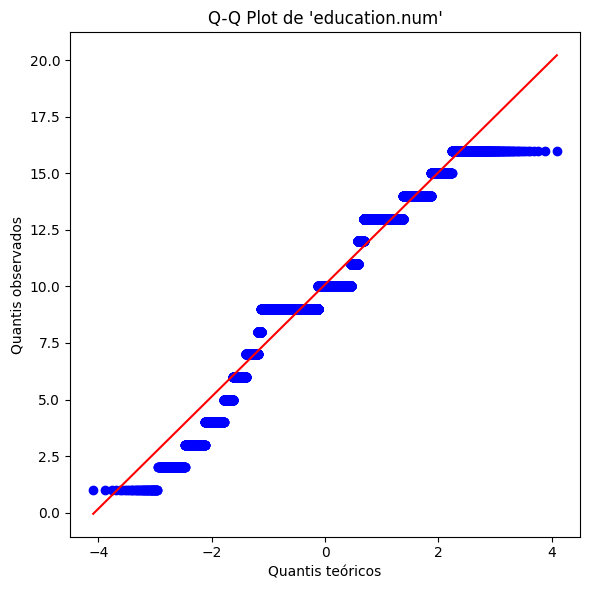

Assimetria             : -0.3095002599899898
Teste Shapiro-Wilk, p-valor:1.3623153312541954e-44

Variável capital.gain:


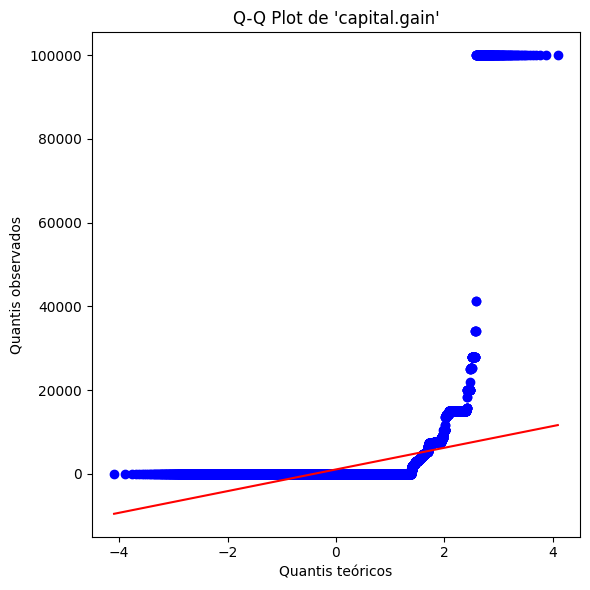

Assimetria             : 11.949402833551472
Teste Shapiro-Wilk, p-valor:9.430901340028029e-93

Variável capital.loss:


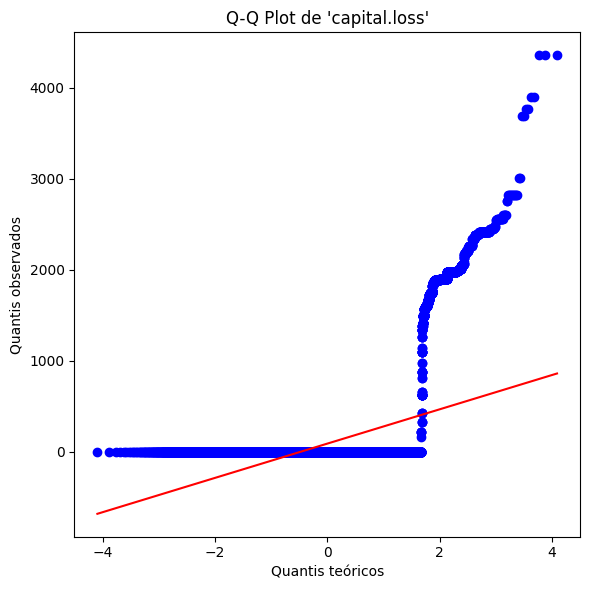

Assimetria             : 4.592702423271813
Teste Shapiro-Wilk, p-valor:4.394264459629973e-90

Variável hours.per.week:


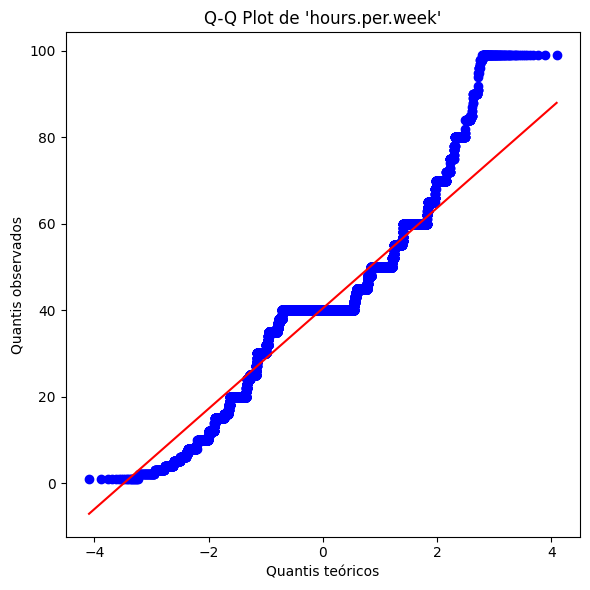

Assimetria             : 0.22875887785250432
Teste Shapiro-Wilk, p-valor:1.0694767585662615e-51


In [ ]:
from scipy import stats
import matplotlib.pyplot as plt

colunas_numericas = [
    "age",
    "fnlwgt",
    "education.num",
    "capital.gain",
    "capital.loss",
    "hours.per.week"
]

alpha = 0.05
tamanho_maximo_shapiro = 5000

variaveis_normais = []
variaveis_nao_normais = []
resultados_normalidade = {}

print_formatado("1. Selecionar método de identificação de outlier:")

print_formatado("1.1. Q-Q Plot, Assimetria, Shapiro-Wilk")
for coluna in colunas_numericas:

    print(f"\nVariável {coluna}:")
    dados = df[coluna].dropna()
    plt.figure(figsize=(6, 6))

    stats.probplot(
        dados,
        dist="norm",
        plot=plt
    )

    plt.title(f"Q-Q Plot de '{coluna}'")
    plt.xlabel("Quantis teóricos")
    plt.ylabel("Quantis observados")
    plt.tight_layout()
    plt.show()

    assimetria = stats.skew(dados, bias=False, nan_policy="omit")
    print(f"Assimetria             : {assimetria}")

    # ---------------------------------------------------------
    # 3. Teste de Shapiro-Wilk
    # ---------------------------------------------------------
    # Para amostras grandes, são selecionadas no máximo
    # 5.000 observações, pois o teste é muito sensível.
    if len(dados) > tamanho_maximo_shapiro:
        dados_teste = dados.sample(
            n=tamanho_maximo_shapiro,
            random_state=1
        )
    else:
        dados_teste = dados

    estatistica_w, p_valor = stats.shapiro(dados_teste)
    print(f"Teste Shapiro-Wilk, p-valor:{p_valor}")


### **Observações Identificação de Outliers e Anomalias**
### 1. Selecionar método de identificação de outlier;
* Nenhuma variável teve os quantis observados próximos dos teóricos para Q-Q plot, logo nenhuma parece seguir uma distribuição normal.
* Nenhuma variável possui grande simetria (skew próximo de 0).
* Nenhuma variável teve p-valor > 0.05, logo nenhuma apresentou indício de distribuição normal.
* Logo, nenhuma variável parece seguir distribuição normal e o método IRQ será utilizado em todas as variáveis.

In [ ]:
variaveis_irq = [
    "age",
    "fnlwgt",
    "education.num",
    "capital.gain",
    "capital.loss",
    "hours.per.week"
]


print_formatado("2. Identificar outliers com IRQ ou Z-Score:")

outliers_por_coluna = {}
indices_outliers = set()

for coluna in variaveis_irq:
    dados = df[coluna].dropna()

    q1 = dados.quantile(0.25)
    q3 = dados.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    mascara_outliers = ((df[coluna] < limite_inferior) | (df[coluna] > limite_superior))
    outliers_coluna = df.loc[mascara_outliers].copy()
    outliers_por_coluna[coluna] = outliers_coluna
    indices_outliers.update(outliers_coluna.index)

    print(f"\nVariável: {coluna}")
    print(f"Q1: {q1:.2f}")
    print(f"Q3: {q3:.2f}")
    print(f"IQR: {iqr:.2f}")
    print(f"Limite inferior: {limite_inferior:.2f}")
    print(f"Limite superior: {limite_superior:.2f}")
    print(f"Quantidade de outliers: {len(outliers_coluna)}")

    display(outliers_coluna[[coluna]].head(10))



2. Identificar outliers com IRQ ou Z-Score:

Variável: age
Q1: 28.00
Q3: 48.00
IQR: 20.00
Limite inferior: -2.00
Limite superior: 78.00
Quantidade de outliers: 142


,age
0,90
1,82
118,83
128,81
199,90
992,80
1180,81
1739,90
1740,79
1742,90



Variável: fnlwgt
Q1: 117827.00
Q3: 236993.00
IQR: 119166.00
Limite inferior: -60922.00
Limite superior: 415742.00
Quantidade de outliers: 993


,fnlwgt
8,422013
101,456062
129,427422
262,816750
305,454508
329,469705
350,445382
417,437727
494,511668
591,459189



Variável: education.num
Q1: 9.00
Q3: 12.00
IQR: 3.00
Limite inferior: 4.50
Limite superior: 16.50
Quantidade de outliers: 1193


...

,capital.gain
1519,99999
1520,99999
1521,99999
1522,99999
1523,99999
1524,99999
1525,99999
1526,99999
1527,99999
1528,99999



Variável: capital.loss
Q1: 0.00
Q3: 0.00
IQR: 0.00
Limite inferior: 0.00
Limite superior: 0.00
Quantidade de outliers: 1519


,capital.loss
0,4356
1,4356
2,4356
3,3900
4,3900
5,3770
6,3770
7,3683
8,3683
9,3004



Variável: hours.per.week
Q1: 40.00
Q3: 45.00
IQR: 5.00
Limite inferior: 32.50
Limite superior: 52.50
Quantidade de outliers: 9002


,hours.per.week
1,18
7,20
9,60
12,20
13,55
16,76
22,25
24,32
26,32
29,90


### **Observações Identificação de Outliers e Anomalias (Continuação)**
### 2. Identificar outliers com IRQ ou ZScore;
* Nenhum possível outlier será removido:
    * `age`: decisão é manter outliers identificados pelo IRQ. Idades acima de 78 anos presentes no dataset ainda podem ser consideradas possíveis. Não houve idades abaixo de -2 anos.
    * `fnlwgt`: decisão é manter outliers identificados pelo IRQ. É uma variável de controle do próprio dataset. Representa quantos indivíduos aquela linha específica representa. Não é uma variável importante para previsão.
    * `education.num`: decisão é manter outliers identificados pelo IRQ. Apesar de ser considera numérica, esta variável poderia ser considerada categórica, pois os valores são inteiros variando de 1 até 16. Todos os valores são possíveis, considerando que representam níveis de escolaridade dos indivíduos.
    * `capital.gain`: decisão é manter outliers identificados pelo IRQ. Existem muitos valores 0, logo o limite inferior e superior do IRQ foram 0. Isso indica que qualquer ganho de capital foi considerado outlier. Muitos valores repetidos 99999, o que provavelmente indica algum tipo de truncamento. Decisão é não remover esses valores, considerando a hipótese de truncamento, pois esses outliers representam indivíduos que possuem uma renda extremamente elevada.
    * `capital.loss`: decisão é manter outliers identificados pelo IRQ. Semelhante ao capital.gain, maior parte dos valores são 0, fazendo com que qualquer perda de capital seja considerada outlier. Logo, decisão é não remover.
    * `hour.per.week`: decisão é manter outliers identificados pelo IRQ. Valores de horas dos outliers ainda não possíveis. Mesmo valores como 90 horas, representariam 15 horas por dia, durante 6 dias, o que é extremo, porém ainda possível.

## **Variáveis Categóricas**

In [ ]:
colunas_categoricas = ["workclass", "education", "marital.status", "occupation",
                        "relationship", "race", "sex", "native.country", "income"]
nivel_desequilibrio = 2
limite_categoria_rara = 0.01

print_formatado("1. Identificar categorias raras:")
for coluna in colunas_categoricas:
    frequencia_relativa = df[coluna].value_counts(
        normalize=True,
        dropna=False
    )

    categorias_raras = frequencia_relativa[
        frequencia_relativa < limite_categoria_rara
    ]

    print(f"\nCategorias raras da variável '{coluna}':")

    if categorias_raras.empty:
        print("Nenhuma categoria rara encontrada.")
    else:
        print((categorias_raras * 100).round(2).astype(str) + "%")


print_formatado("2. Identificar possível desiquilíbrio entre classes:")
for coluna in colunas_categoricas:
    contagem = df[coluna].value_counts(dropna=False)

    maior_frequencia = contagem.max()
    menor_frequencia = contagem.min()
    razao_desequilibrio = maior_frequencia / menor_frequencia

    print(f"\nVariável '{coluna}':")
    print(f"Maior frequência: {maior_frequencia}")
    print(f"Menor frequência: {menor_frequencia}")
    print(f"Razão maior/menor frequência: {razao_desequilibrio:.2f}")

    if razao_desequilibrio >= nivel_desequilibrio:
        print("Conclusão: Possível desequilíbrio.")
    else:
        print("Conclusão: Sem desequilíbrio.")



1. Identificar categorias raras:

Categorias raras da variável 'workclass':
workclass
Without-pay     0.04%
Never-worked    0.02%
Name: proportion, dtype: object

Categorias raras da variável 'education':
education
1st-4th      0.51%
Preschool    0.15%
Name: proportion, dtype: object

Categorias raras da variável 'marital.status':
marital.status
Married-AF-spouse    0.07%
Name: proportion, dtype: object

Categorias raras da variável 'occupation':
occupation
Priv-house-serv    0.45%
Armed-Forces       0.03%
Name: proportion, dtype: object

Categorias raras da variável 'relationship':
Nenhuma categoria rara encontrada.

Categorias raras da variável 'race':
race
Amer-Indian-Eskimo    0.96%
Other                 0.83%
Name: proportion, dtype: object

Categorias raras da variável 'sex':
Nenhuma categoria rara encontrada.

Categorias raras da variável 'native.country':
native.country
Philippines                   0.61%
Germany                       0.42%
Canada                        0.37%

### **Observações Identificar Outliers e anomalias (continuação)**
### 1. Identificar categorias raras
* `native.country`: a maior parte dos países possuem frequência abaixo de 1% e USA contém a maior parte dos exemplos. Como o dataset é sobre indivíduos de USA, é um comportamento esperado. Logo, foi decidido criar uma nova coluna `native.contry.grouped` que agrupa os países que não são USA.
* demais países: não é possível identificar um desequilíbrio significativo, logo todas as categorias foram preservadas.

In [ ]:
limite_percentual = 0.01

proporcoes = df["native.country"].value_counts(normalize=True, dropna=False)
paises_raros = proporcoes[proporcoes < limite_percentual].index
df["native.country_agrupada"] = (df["native.country"].astype("string"))
df.loc[df["native.country"].isin(paises_raros) & df["native.country"].notna(), "native.country_agrupada"] = "Other"

print(df["native.country_agrupada"].value_counts(dropna=False))
display(df.sample(20))

native.country_agrupada
United-States    29153
Other             2163
Mexico             639
Desconhecido       582
Name: count, dtype: Int64


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income,income_binaria,native.country_agrupada
19761,33,Private,392812,Some-college,10,Married-civ-spouse,Handlers-cleaners,Husband,White,Male,0,0,50,United-States,>50K,1,United-States
19134,28,Private,185127,Some-college,10,Never-married,Sales,Not-in-family,White,Male,0,0,40,United-States,<=50K,0,United-States
28929,24,Desconhecido,265434,Bachelors,13,Never-married,Desconhecido,Not-in-family,White,Female,0,0,40,United-States,<=50K,0,United-States
26110,24,Private,176321,Some-college,10,Never-married,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K,0,United-States
16529,35,Private,339772,HS-grad,9,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0,United-States
28710,33,Self-emp-not-inc,182926,Bachelors,13,Never-married,Transport-moving,Not-in-family,White,Male,0,0,40,Desconhecido,<=50K,0,Desconhecido
24242,35,Private,98389,11th,7,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,40,United-States,<=50K,0,United-States
6445,24,State-gov,166851,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,13,United-States,<=50K,0,United-States
12741,49,Desconhecido,174702,Some-college,10,Never-married,Desconhecido,Not-in-family,White,Male,0,0,35,United-States,<=50K,0,United-States
3052,48,State-gov,118330,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K,1,United-States


# **Conclusões**

## **Principais Achados:**
* A base possuía **32.561 registros** e, após a remoção de **24 duplicatas**, passou a ter **32.537 registros**.

* Foram encontrados valores ausentes representados por `?` em `workclass`, `occupation` e `native.country`. Esses valores foram substituídos por `Desconhecido`.

* A variável-alvo `income` está desequilibrada:

  * Aproximadamente **76%** recebem `<=50K`.
  * Aproximadamente **24%** recebem `>50K`.

* As variáveis numéricas com maior relação com a renda foram:

  * `education.num`
  * `age`
  * `hours.per.week`
  * `capital.gain`

* As variáveis categóricas com maior associação com a renda foram:

  * `relationship`
  * `marital.status`
  * `education`
  * `occupation`

* Não foram encontradas correlações fortes entre as variáveis numéricas independentes, indicando baixa multicolinearidade.

* Foram identificadas possíveis redundâncias entre:

  * `relationship`, `marital.status` e `sex`
  * `education` e `education.num`

* A variável `fnlwgt` apresentou pouca relação com a renda e deve ser testada em modelos com e sem sua utilização.

* Nenhuma variável numérica apresentou distribuição normal.

* Foram identificados muitos possíveis outliers pelo método IQR, mas eles não foram removidos, pois podem representar valores reais e relevantes.

* `capital.gain` e `capital.loss` possuem muitos valores iguais a zero, o que faz o método IQR classificar praticamente todos os valores positivos como outliers.

* As categorias raras de `native.country` foram agrupadas em `Other`, reduzindo a quantidade de categorias.

## **Operações realizadas**

* Inspeção da estrutura e dos tipos de dados.
* Verificação de valores ausentes, duplicados e inconsistências.
* Remoção de duplicatas completas.
* Substituição de `?` por `Desconhecido`.
* Conversão das colunas categóricas para o tipo `category`.
* Análise univariada das variáveis.
* Análise de correlação de Pearson e Spearman.
* Aplicação de qui-quadrado e V de Cramér.
* Verificação de normalidade.
* Identificação de outliers pelo IQR.
* Agrupamento de categorias raras.


